# CCS3440_AI-Final-Assignment_Group-02

# Option C: Disease Risk Classification - SmartCare Hospital

# Task 02 – Dataset Understanding

## Mount Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# change this path to wherever you put your files in Drive
folder = '/content/drive/MyDrive/SmartCare/'

df = pd.read_csv(folder + 'smartcare_ai_dataset_1000.csv')
data_dict = pd.read_csv(folder + 'smartcare_ai_dataset_data_dictionary.csv')

print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## 2.1 Dataset Overview

In [ ]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

## 2.2 Attribute Description

In [ ]:
# Data dictionary (attribute meanings)
data_dict

,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


## 2.3  Identify target variables.

In [ ]:
# Target variable for Option C
df['disease_risk_level'].value_counts()

,count
disease_risk_level,
Medium,469
High,400
Low,131


In [ ]:
# Missing values check
df.isnull().sum()[df.isnull().sum() > 0]

,0
room_type,906


In [ ]:
# Check missing room_type by admitted status
pd.crosstab(df['admitted'], df['room_type'].isnull(), rownames=['admitted'], colnames=['room_type_is_null'])


room_type_is_null,False,True
admitted,,
0,0,670
1,94,236


In [ ]:
# Check for duplicate rows
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicate patient_id + appointment_date combos:',
      df.duplicated(subset=['patient_id','appointment_date']).sum())

Fully duplicated rows: 0
Duplicate patient_id + appointment_date combos: 0


In [ ]:
# Check data quality
quality_report = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
}).sort_values('pct_missing', ascending=False)
quality_report

,dtype,n_missing,pct_missing,n_unique
room_type,object,906,90.6,3
record_id,int64,0,0.0,1000
patient_id,object,0,0.0,1000
gender,object,0,0.0,2
age,int64,0,0.0,88
department,object,0,0.0,7
diagnosis,object,0,0.0,10
appointment_date,object,0,0.0,339
blood_group,object,0,0.0,8
waiting_days,int64,0,0.0,45


# Task 03 – Data Preprocessing and Feature Engineering

## 3.1 Missing value handling

In [ ]:
# Missing Values Handling
df.isnull().sum()[df.isnull().sum() > 0]

pd.crosstab(df['admitted'], df['room_type'].isnull())

df_clean = df.copy()

# admitted=0 -> genuinely "no room", meaningful category
df_clean.loc[df_clean['admitted'] == 0, 'room_type'] = \
    df_clean.loc[df_clean['admitted'] == 0, 'room_type'].fillna('Not Admitted')

# admitted=1 but still missing -> real data gap, fill with most common room type
mode_room = df_clean.loc[df_clean['admitted'] == 1, 'room_type'].mode()[0]
df_clean.loc[df_clean['admitted'] == 1, 'room_type'] = \
    df_clean.loc[df_clean['admitted'] == 1, 'room_type'].fillna(mode_room)

print("Remaining missing values:", df_clean['room_type'].isnull().sum())
print(df_clean['room_type'].value_counts())

Remaining missing values: 0
room_type
Not Admitted    670
General Ward    288
Private Room     33
ICU               9
Name: count, dtype: int64


## 3.2 Duplicate record detection

In [ ]:
# Duplicate Record Detection
full_row_dupes = df.duplicated().sum()
patient_id_dupes = df['patient_id'].duplicated().sum()
record_id_dupes = df['record_id'].duplicated().sum()

print(f"Fully duplicated rows        : {full_row_dupes}")
print(f"Duplicated patient_id values : {patient_id_dupes}")
print(f"Duplicated record_id values  : {record_id_dupes}")

df_clean = df_clean.drop_duplicates()

Fully duplicated rows        : 0
Duplicated patient_id values : 0
Duplicated record_id values  : 0


## 3.3 Outlier identification

In [ ]:
# Outlier identificatio (IQR method)
numeric_cols = ['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl','total_bill_lkr']

for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
bmi: 9 outliers
systolic_bp: 3 outliers
diastolic_bp: 3 outliers
blood_sugar_mg_dl: 10 outliers
cholesterol_mg_dl: 6 outliers
total_bill_lkr: 59 outliers


## 3.4 Feature Engineering

In [ ]:
# Feature Engineering
df_feat = df_clean.copy()

df_feat['appointment_date'] = pd.to_datetime(df_feat['appointment_date'])

# Age group — standard clinical age bands
df_feat['age_group'] = pd.cut(
    df_feat['age'], bins=[0, 17, 35, 50, 65, 120],
    labels=['Under 18', '18-35', '36-50', '51-65', '65+']
)

# BMI category — WHO standard cutoffs
df_feat['bmi_category'] = pd.cut(
    df_feat['bmi'], bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Blood pressure category — clinical staging (systolic-led)
def bp_category(row):
    s, d = row['systolic_bp'], row['diastolic_bp']
    if s < 120 and d < 80:
        return 'Normal'
    elif s < 130 and d < 80:
        return 'Elevated'
    else:
        return 'Stage 1 Hypertension'
df_feat['bp_category'] = df_feat.apply(bp_category, axis=1)

# Missed-appointment rate (guard against divide-by-zero)
df_feat['missed_appointment_rate'] = np.where(
    df_feat['previous_appointments'] > 0,
    df_feat['missed_previous_appointments'] / df_feat['previous_appointments'],
    0.0
)

# Chronic-patient flag — repeat admissions signal a chronic condition
df_feat['is_chronic_patient'] = (df_feat['previous_admissions'] >= 2).astype(int)

# Care intensity — combined labs + treatments in this visit
df_feat['care_intensity'] = df_feat['lab_tests_count'] + df_feat['treatments_count']

# Appointment seasonality
df_feat['appointment_month'] = df_feat['appointment_date'].dt.month
df_feat['appointment_quarter'] = df_feat['appointment_date'].dt.quarter

# Convert pd.cut Categorical outputs to plain strings (needed before encoding)
df_feat['age_group'] = df_feat['age_group'].astype(str)
df_feat['bmi_category'] = df_feat['bmi_category'].astype(str)

print("Shape after feature engineering:", df_feat.shape)
df_feat.head()

Shape after feature engineering: (1000, 41)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level,age_group,bmi_category,bp_category,missed_appointment_rate,is_chronic_patient,care_intensity,appointment_month,appointment_quarter
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,Not Admitted,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High,51-65,Overweight,Elevated,0.000000,0,3,4,2
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,Not Admitted,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium,18-35,Obese,Stage 1 Hypertension,0.333333,0,1,5,2
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,Not Admitted,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium,18-35,Overweight,Stage 1 Hypertension,0.142857,0,1,7,3
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,Not Admitted,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium,36-50,Normal,Stage 1 Hypertension,0.000000,0,3,10,4
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,Not Admitted,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium,51-65,Overweight,Stage 1 Hypertension,0.000000,0,2,12,4


## 3.5 Data Cleaning

In [ ]:
# Data Cleaning - drop irrelevant / leakage columns
drop_cols = ['record_id', 'patient_id', 'appointment_date', 'no_show', 'readmitted_30_days']
df_model = df_feat.drop(columns=drop_cols)   # built from df_feat (keeps engineered features)

print("Shape after cleaning:", df_model.shape)

Shape after cleaning: (1000, 36)


## 3.6 Save Cleaned Dataset

In [ ]:
# Save cleaned dataset (once — human-readable, before encoding)

df_feat.to_csv(folder + 'smartcare_cleaned.csv', index=False)
print("Saved:", folder + 'smartcare_cleaned.csv', df_feat.shape)

from google.colab import files
files.download(folder + 'smartcare_cleaned.csv')

Saved: /content/drive/MyDrive/SmartCare/smartcare_cleaned.csv (1000, 41)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3.7 Train/Test Split

In [ ]:
# TRAIN/TEST SPLIT — now done FIRST, before encoding/selection/scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y_all = pd.Series(
    target_encoder.fit_transform(df_model['disease_risk_level']),
    index=df_model.index,
    name='disease_risk_level'
)
X_all = df_model.drop(columns=['disease_risk_level'])

print("Target classes (index -> label):", list(enumerate(target_encoder.classes_)))

pd.Series(target_encoder.classes_, name='class_name').to_csv(
    folder + 'target_classes.csv', index_label='encoded_value'
)
print("Saved true class order to:", folder + 'target_classes.csv')

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print("Train size:", X_train_raw.shape, "Test size:", X_test_raw.shape)


Target classes (index -> label): [(0, 'High'), (1, 'Low'), (2, 'Medium')]
Saved true class order to: /content/drive/MyDrive/SmartCare/target_classes.csv
Train size: (800, 35) Test size: (200, 35)


## 3.8 Feature Encoding

In [ ]:
# Feature Encoding — fit on TRAIN ONLY, then apply the same mapping to test
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Ordinal: engineered bands with a genuine natural order
ordinal_cols = ['age_group', 'bmi_category', 'bp_category']
ordinal_categories = [
    ['Under 18', '18-35', '36-50', '51-65', '65+'],
    ['Underweight', 'Normal', 'Overweight', 'Obese'],
    ['Normal', 'Elevated', 'Stage 1 Hypertension'],
]

# Nominal: no inherent order — one-hot encode instead of label/ordinal encode
nominal_cols = ['gender', 'blood_group', 'department', 'diagnosis',
                 'appointment_status', 'room_type', 'payment_status', 'payment_method']

other_cols = [c for c in X_train_raw.columns if c not in ordinal_cols + nominal_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=ordinal_categories,
                                handle_unknown='use_encoded_value', unknown_value=-1),
         ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         nominal_cols),
        ('num', 'passthrough', other_cols),
    ]
)

preprocessor.fit(X_train_raw)  # <-- train data only

encoded_feature_names = (
    ordinal_cols +
    list(preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols)) +
    other_cols
)

X_train_enc = pd.DataFrame(
    preprocessor.transform(X_train_raw),
    columns=encoded_feature_names,
    index=X_train_raw.index
)
X_test_enc = pd.DataFrame(
    preprocessor.transform(X_test_raw),
    columns=encoded_feature_names,
    index=X_test_raw.index
)

print("Encoding complete. Train shape:", X_train_enc.shape, "Test shape:", X_test_enc.shape)
X_train_enc.head()

Encoding complete. Train shape: (800, 69) Test shape: (200, 69)


,age_group,bmi_category,bp_category,gender_Female,gender_Male,blood_group_A+,blood_group_A-,blood_group_AB+,blood_group_AB-,blood_group_B+,blood_group_B-,blood_group_O+,blood_group_O-,department_Cardiology,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Asthma,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,...,payment_method_Online,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,missed_appointment_rate,is_chronic_patient,care_intensity,appointment_month,appointment_quarter
691,3.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,52.0,15.0,1.0,0.0,0.0,0.0,0.0,145.0,69.0,119.0,176.0,28.5,1.0,1.0,4000.0,0.0,1800.0,7182.0,12982.0,0.0,0.0,2.0,3.0,1.0
357,4.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,82.0,28.0,5.0,1.0,0.0,0.0,2.0,141.0,89.0,102.0,214.0,26.9,4.0,3.0,2500.0,0.0,12000.0,5235.0,19735.0,0.2,1.0,7.0,12.0,4.0
789,3.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,57.0,35.0,2.0,1.0,0.0,0.0,2.0,166.0,72.0,136.0,229.0,26.5,1.0,0.0,3500.0,0.0,1200.0,5818.0,10518.0,0.5,1.0,1.0,1.0,1.0
179,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,15.0,8.0,1.0,0.0,0.0,0.0,4.0,154.0,78.0,126.0,162.0,21.5,1.0,3.0,2000.0,0.0,3000.0,678.0,5678.0,0.0,1.0,4.0,9.0,3.0
309,3.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,61.0,37.0,2.0,0.0,0.0,0.0,1.0,155.0,89.0,138.0,195.0,18.5,0.0,2.0,2000.0,0.0,0.0,6950.0,8950.0,0.0,0.0,2.0,6.0,2.0


## 3.9 Feature Selection

In [ ]:
# Feature Selection — fit on TRAIN ONLY
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_train_enc, y_train)  # <-- train data only

scores = pd.DataFrame({
    'feature': X_train_enc.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)
print(scores)

selected_features = scores['feature'].head(15).tolist()
print("\nSelected features (from training data only):", selected_features)

X_train_selected = X_train_enc[selected_features]
X_test_selected = X_test_enc[selected_features]   # same columns, no fitting on test

                          feature       score
45                            age  170.145696
0                       age_group  151.593123
54              blood_sugar_mg_dl  110.272227
55              cholesterol_mg_dl  108.109114
56                            bmi   56.416698
..                            ...         ...
5                  blood_group_A+    0.076110
50            length_of_stay_days    0.071725
64        missed_appointment_rate    0.054674
61                 lab_charge_lkr    0.021131
39  payment_status_Partially Paid    0.016377

[69 rows x 2 columns]

Selected features (from training data only): ['age', 'age_group', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'systolic_bp', 'bmi_category', 'bp_category', 'previous_admissions', 'is_chronic_patient', 'diagnosis_Diabetes', 'department_Orthopedics', 'appointment_status_Cancelled', 'department_Cardiology', 'blood_group_AB+']


## 3.10 Feature Scaling

In [ ]:
# Feature Scaling — fit on TRAIN ONLY, transform both splits with those statistics
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_selected),   # <-- fit on train only
    columns=selected_features,
    index=X_train_selected.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_selected),        # <-- test only ever transformed
    columns=selected_features,
    index=X_test_selected.index
)

# Persist the fitted scaler itself, not just the scaled data. Task 08's
# prototype model reuses this exact scaler's parameters (subset to its 5
# features) instead of fitting a new one on a different pipeline.
import joblib
joblib.dump(scaler, folder + 'feature_scaler_main.pkl')
print("Saved main fitted scaler to:", folder + 'feature_scaler_main.pkl')

X_train_scaled.head()

Saved main fitted scaler to: /content/drive/MyDrive/SmartCare/feature_scaler_main.pkl


,age,age_group,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,systolic_bp,bmi_category,bp_category,previous_admissions,is_chronic_patient,diagnosis_Diabetes,department_Orthopedics,appointment_status_Cancelled,department_Cardiology,blood_group_AB+
691,0.411134,0.806267,0.162288,-0.803788,0.698872,1.062265,0.443537,0.600961,-0.883265,-0.513637,-0.335643,-0.411814,-0.246998,-0.434405,-0.373632
357,2.090375,1.721181,-0.492449,0.253782,0.318064,0.803748,0.443537,0.600961,1.198067,1.946900,-0.335643,2.428282,-0.246998,-0.434405,-0.373632
789,0.691008,0.806267,0.817026,0.671244,0.222862,2.419483,0.443537,0.600961,1.198067,1.946900,-0.335643,-0.411814,-0.246998,-0.434405,-0.373632
179,-1.659929,-1.938473,0.431886,-1.193419,-0.967163,1.643930,-0.810278,0.600961,3.279398,1.946900,-0.335643,-0.411814,-0.246998,-0.434405,-0.373632
309,0.914906,0.806267,0.894054,-0.275003,-1.681178,1.708560,-2.064093,0.600961,0.157401,-0.513637,-0.335643,2.428282,-0.246998,-0.434405,-0.373632


## 3.11 Save Model-Ready Splits

In [ ]:
# Save model-ready splits (Task 05) — X_train/X_test are now leakage-free:
# encoding, feature selection, and scaling were all fit on X_train only.
X_train_scaled.to_csv(folder + 'X_train.csv', index=False)
X_test_scaled.to_csv(folder + 'X_test.csv', index=False)
y_train.to_csv(folder + 'y_train.csv', index=False)
y_test.to_csv(folder + 'y_test.csv', index=False)

print("Saved to Drive:", folder)

from google.colab import files
files.download(folder + 'X_train.csv')
files.download(folder + 'X_test.csv')
files.download(folder + 'y_train.csv')
files.download(folder + 'y_test.csv')

Saved to Drive: /content/drive/MyDrive/SmartCare/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 04 – Exploratory Data Analysis (EDA)

## 4.1 Load Cleaned Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

folder = '/content/drive/MyDrive/SmartCare/'
df_feat = pd.read_csv(folder + 'smartcare_cleaned.csv')
df_feat['appointment_date'] = pd.to_datetime(df_feat['appointment_date'])

print(df_feat.shape)
df_feat.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1000, 41)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level,age_group,bmi_category,bp_category,missed_appointment_rate,is_chronic_patient,care_intensity,appointment_month,appointment_quarter
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,Not Admitted,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High,51-65,Overweight,Elevated,0.000000,0,3,4,2
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,Not Admitted,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium,18-35,Obese,Stage 1 Hypertension,0.333333,0,1,5,2
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,Not Admitted,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium,18-35,Overweight,Stage 1 Hypertension,0.142857,0,1,7,3
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,Not Admitted,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium,36-50,Normal,Stage 1 Hypertension,0.000000,0,3,10,4
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,Not Admitted,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium,51-65,Overweight,Stage 1 Hypertension,0.000000,0,2,12,4


## 4.2 Descriptive Statistics

In [ ]:
df_feat[['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']].describe().round(1)

,age,bmi,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl
count,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
mean,44.7,25.5,128.4,78.8,114.8,204.8
std,17.9,4.3,15.5,10.0,26.0,36.6
min,1.0,14.0,85.0,50.0,65.0,100.0
25%,33.0,22.7,117.0,72.0,97.0,180.0
50%,44.0,25.6,128.0,79.0,114.0,204.0
75%,57.0,28.3,139.0,86.0,132.0,230.0
max,90.0,38.8,178.0,111.0,201.0,330.0


In [ ]:
# Mean of clinical values grouped by risk level
df_feat.groupby('disease_risk_level')[['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']].mean().round(1)

,age,bmi,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl
disease_risk_level,,,,,,
High,55.4,27.2,134.2,79.5,128.7,222.5
Low,27.6,22.6,121.1,76.6,93.3,174.2
Medium,40.5,24.9,125.6,78.8,109.0,198.3


In [ ]:
# Risk level distribution across the engineered age_group feature
df_feat.groupby('age_group', observed=True)['disease_risk_level'].value_counts().unstack()

disease_risk_level,High,Low,Medium
age_group,,,
18-35,39.0,67.0,145.0
36-50,110.0,33.0,175.0
51-65,147.0,5.0,101.0
65+,100.0,NaN,20.0
Under 18,4.0,26.0,28.0


## 4.3 Correlation Analysis

In [ ]:
# Correlation Analysis
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['risk_num'] = df['disease_risk_level'].map(risk_map)

corr_target = df[numeric_cols + ['risk_num']].corr()['risk_num'].drop('risk_num').sort_values(key=abs, ascending=False)
print("Correlation of numeric features with disease_risk_level (ordinal-encoded):")
print(corr_target.round(3))

Correlation of numeric features with disease_risk_level (ordinal-encoded):
age                  0.538
blood_sugar_mg_dl    0.474
cholesterol_mg_dl    0.447
bmi                  0.360
systolic_bp          0.311
diastolic_bp         0.084
total_bill_lkr       0.012
Name: risk_num, dtype: float64


## 4.4 Class Distribution Charts

/tmp/ipykernel_962/265401370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='disease_risk_level', data=df_feat, order=['Low','Medium','High'], palette='viridis')


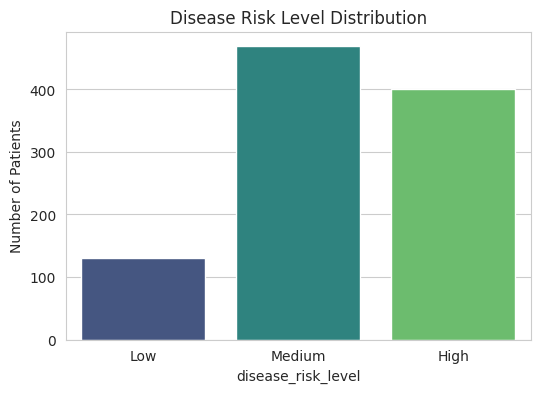

In [ ]:
# Class Distribution Chart
plt.figure(figsize=(6,4))
sns.countplot(x='disease_risk_level', data=df_feat, order=['Low','Medium','High'], palette='viridis')
plt.title('Disease Risk Level Distribution')
plt.ylabel('Number of Patients')
plt.show()

## 4.5 Histograms

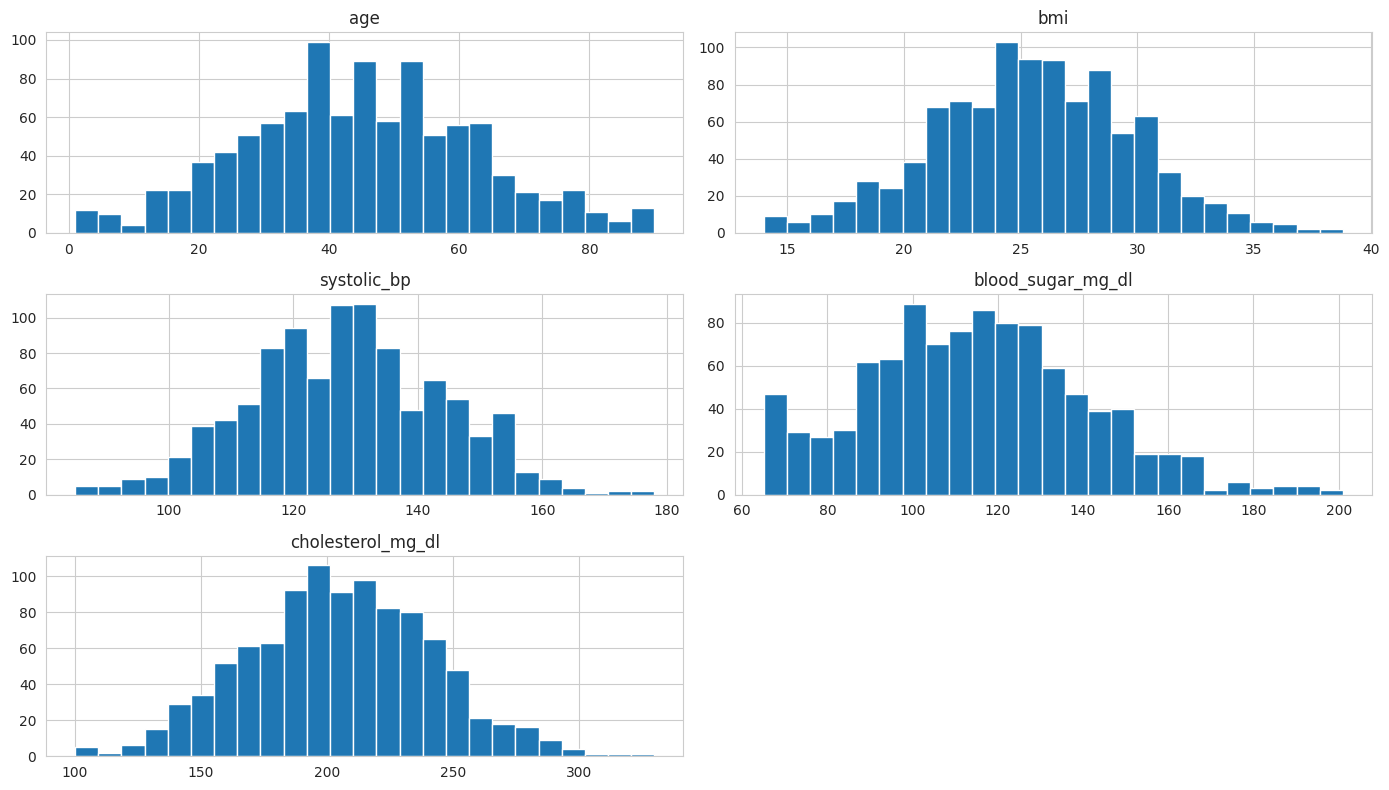

In [ ]:
# Histograms — Distribution Analysis
df_feat[['age','bmi','systolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']].hist(figsize=(14,8), bins=25)
plt.tight_layout()
plt.show()

## 4.6 Boxplots

/tmp/ipykernel_962/1241888459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
/tmp/ipykernel_962/1241888459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
/tmp/ipykernel_962/1241888459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
/tmp

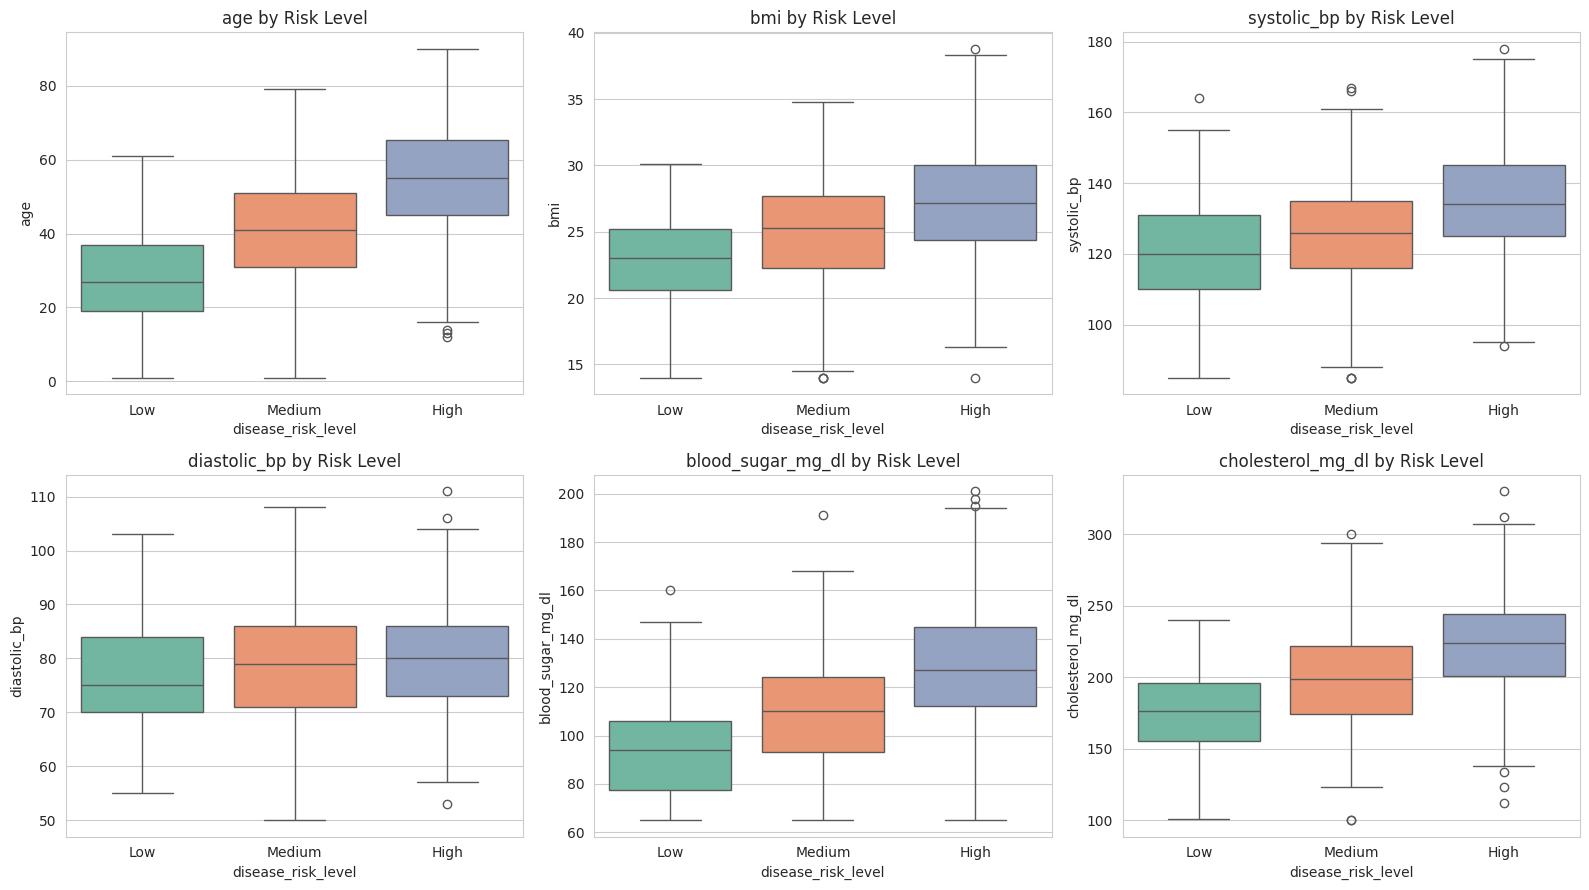

In [ ]:
# Boxplots
fig, axes = plt.subplots(2, 3, figsize=(16,9))
cols = ['age','bmi','systolic_bp','diastolic_bp','blood_sugar_mg_dl','cholesterol_mg_dl']
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(x='disease_risk_level', y=col, data=df_feat, order=['Low','Medium','High'], ax=ax, palette='Set2')
    ax.set_title(f'{col} by Risk Level')
plt.tight_layout()
plt.show()

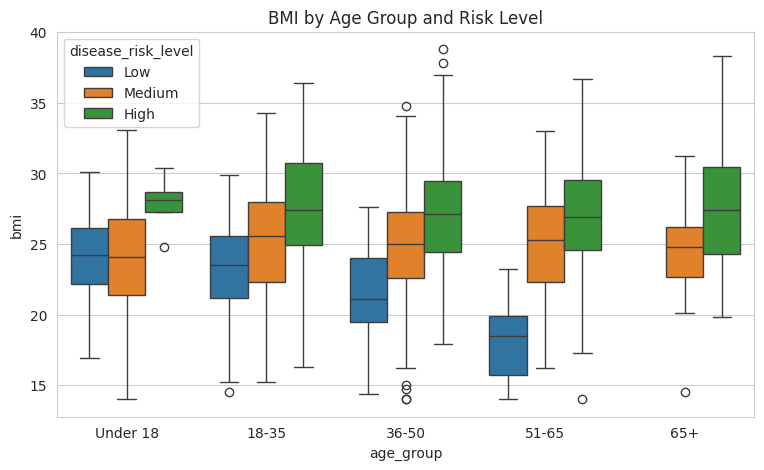

In [ ]:
# Bonus: BMI by age_group and risk level (uses engineered feature)
plt.figure(figsize=(9,5))
sns.boxplot(x='age_group', y='bmi', hue='disease_risk_level',
            order=['Under 18','18-35','36-50','51-65','65+'],
            hue_order=['Low','Medium','High'], data=df_feat)
plt.title('BMI by Age Group and Risk Level')
plt.show()

## 4.7 Scatterplots — Pattern Discovery

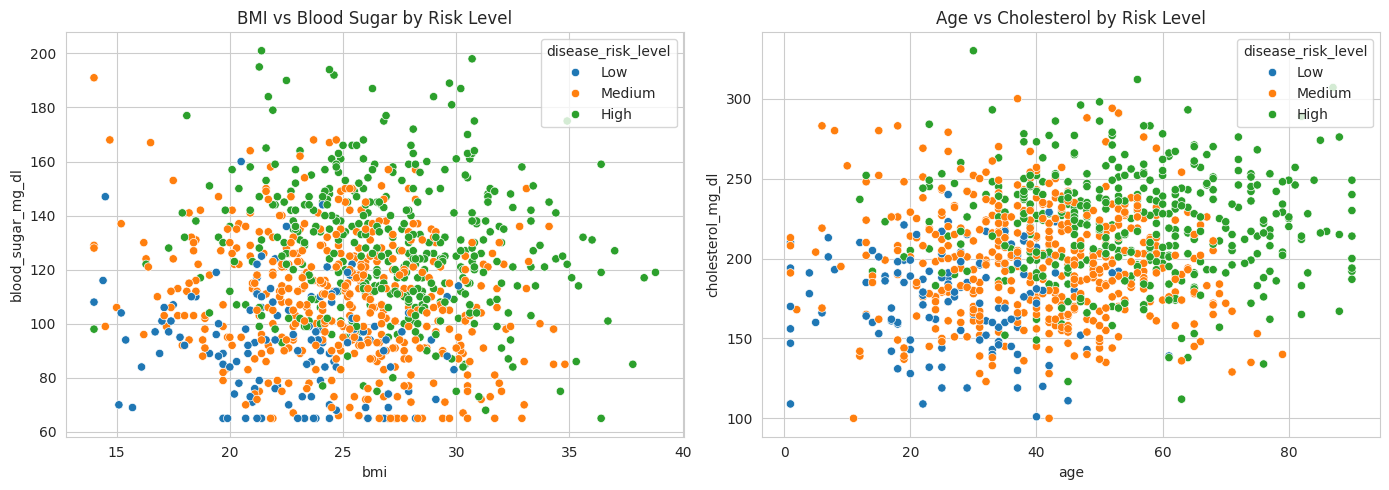

In [ ]:
# Scatterplots — Pattern Discovery
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x='bmi', y='blood_sugar_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], data=df_feat, ax=axes[0])
axes[0].set_title('BMI vs Blood Sugar by Risk Level')

sns.scatterplot(x='age', y='cholesterol_mg_dl', hue='disease_risk_level',
                 hue_order=['Low','Medium','High'], data=df_feat, ax=axes[1])
axes[1].set_title('Age vs Cholesterol by Risk Level')
plt.tight_layout()
plt.show()

## 4.8 Correlation Heatmap

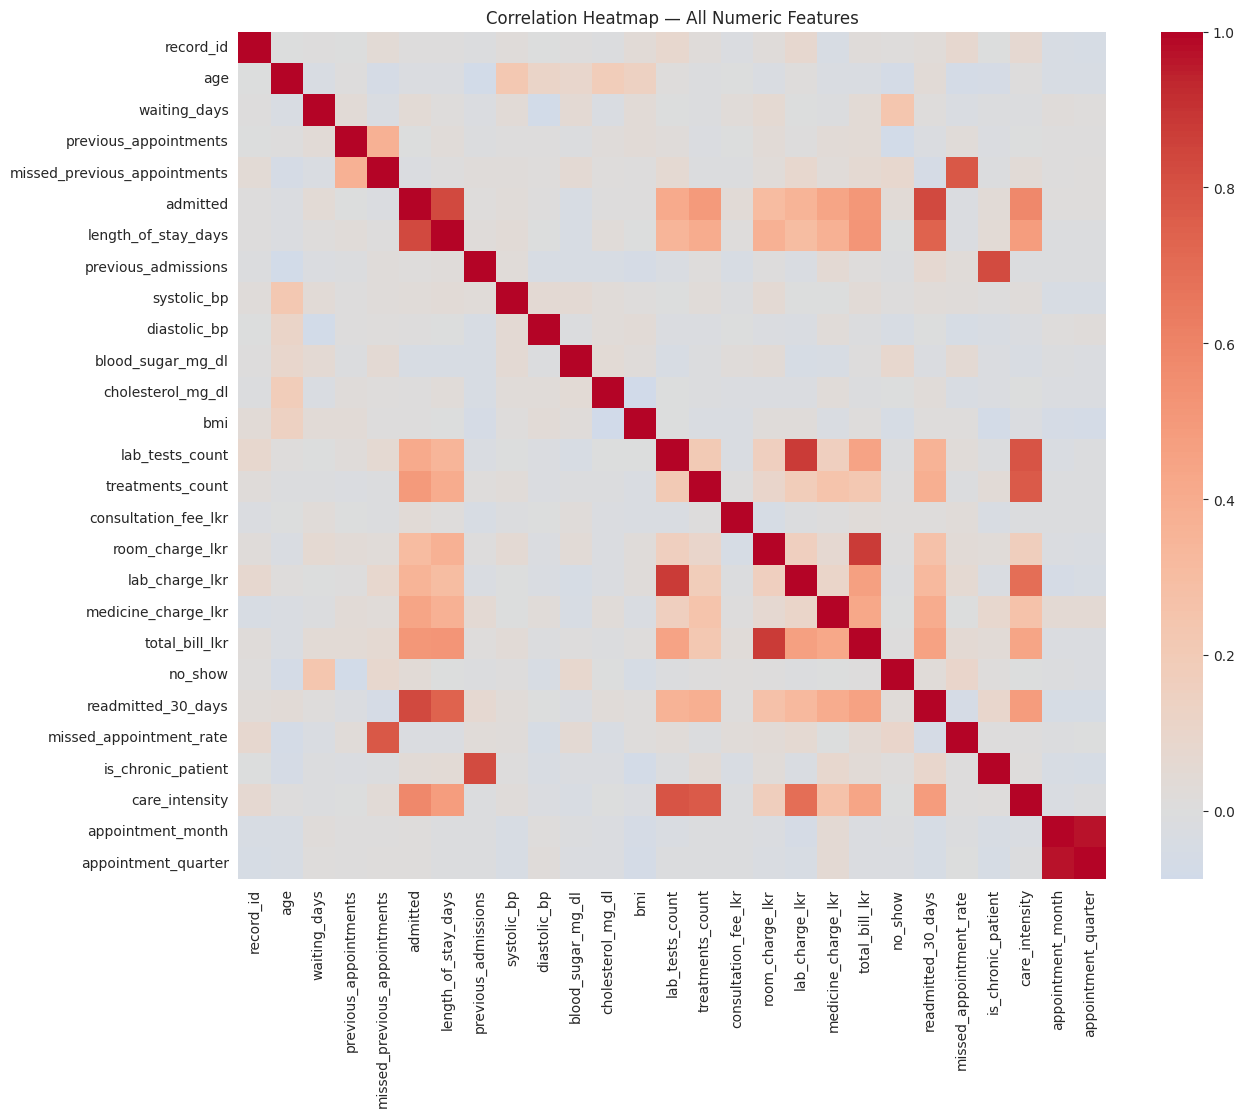

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(14,11))
corr = df_feat.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — All Numeric Features')
plt.show()

<Figure size 800x500 with 0 Axes>

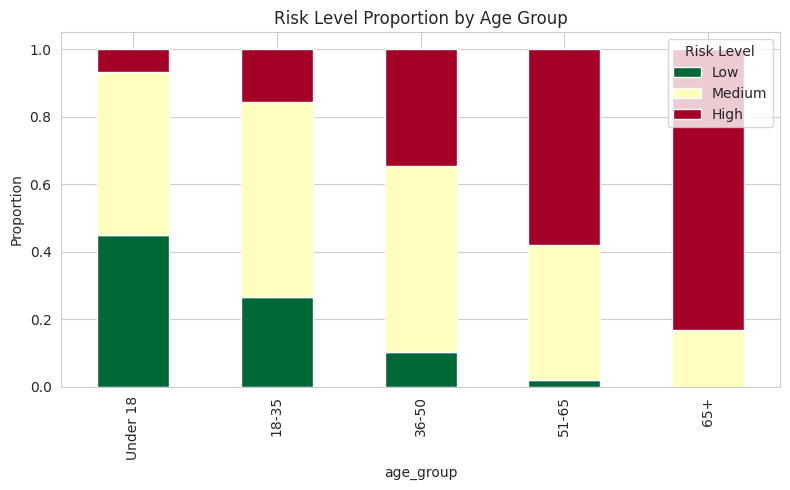

In [ ]:
# Bonus — Risk Level Proportion by Age Group (stacked bar)
plt.figure(figsize=(8,5))
age_risk = df_feat.groupby('age_group', observed=True)['disease_risk_level'].value_counts(normalize=True).unstack()
age_risk = age_risk.reindex(['Under 18','18-35','36-50','51-65','65+'])
age_risk[['Low','Medium','High']].plot(kind='bar', stacked=True, colormap='RdYlGn_r', figsize=(8,5))
plt.title('Risk Level Proportion by Age Group')
plt.ylabel('Proportion')
plt.legend(title='Risk Level')
plt.tight_layout()
plt.show()

# Task 05 – Machine Learning Model Development

In [ ]:
try:
    import xgboost
except ImportError:
    import sys
# [Jupyter shell]     !{sys.executable} -m pip install xgboost -q
    import xgboost

print("xgboost version:", xgboost.__version__)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_STATE = 42
CLASS_NAMES = ['Low', 'Medium', 'High']   # target encoding: 0=Low, 1=Medium, 2=High (from Task 03)

# Define folder path (assuming drive is already mounted)
folder = '/content/drive/MyDrive/SmartCare/' # Added this line to define the 'folder' variable

X_train = pd.read_csv(folder + 'X_train.csv') # Changed path
y_train = pd.read_csv(folder + 'y_train.csv').squeeze() # Changed path
X_test = pd.read_csv(folder + 'X_test.csv') # Changed path
y_test = pd.read_csv(folder + 'y_test.csv').squeeze() # Changed path

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).sort_index().round(3))
print("\nTest class distribution:\n",  y_test.value_counts(normalize=True).sort_index().round(3))


xgboost version: 3.3.0
Train: (800, 15)  Test: (200, 15)

Train class distribution:
 disease_risk_level
0    0.400
1    0.131
2    0.469
Name: proportion, dtype: float64

Test class distribution:
 disease_risk_level
0    0.40
1    0.13
2    0.47
Name: proportion, dtype: float64


## 5.1 Model Training & 5.2 Hyperparameter Selection

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}       # will hold fitted best estimators
cv_summary = []     # will hold tuning summary rows

def tune_and_report(name, estimator, param_grid, X, y, fit_params=None):
    start = time.time()
    grid = GridSearchCV(estimator, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1, refit=True)
    grid.fit(X, y, **(fit_params or {}))
    elapsed = time.time() - start
    best_idx = grid.best_index_
    best_std = grid.cv_results_['std_test_score'][best_idx]
    print(f"{name:22s} | best CV macro-F1 = {grid.best_score_:.4f} ± {best_std:.4f} | best params = {grid.best_params_} | {elapsed:.1f}s")
    results[name] = grid.best_estimator_
    cv_summary.append({
        'Model': name,
        'Best CV Macro-F1': grid.best_score_,
        'CV Std': best_std,
        'Best Params': grid.best_params_
    })
    return grid.best_estimator_

### Model 1 — Logistic Regression

In [ ]:
lr_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [2000],
    'class_weight': ['balanced'],
}
best_lr = tune_and_report('Logistic Regression', LogisticRegression(random_state=RANDOM_STATE), lr_grid, X_train, y_train)

Logistic Regression    | best CV macro-F1 = 0.9706 ± 0.0148 | best params = {'C': 10, 'class_weight': 'balanced', 'max_iter': 2000, 'penalty': 'l2', 'solver': 'lbfgs'} | 7.7s


### Model 2 — Decision Tree

In [ ]:
dt_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced'],
}
best_dt = tune_and_report('Decision Tree', DecisionTreeClassifier(random_state=RANDOM_STATE), dt_grid, X_train, y_train)

Decision Tree          | best CV macro-F1 = 0.7381 ± 0.0274 | best params = {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2} | 4.5s


### Model 3 — Random Forest

In [ ]:
rf_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3, 5],
    'class_weight': ['balanced'],
}
best_rf = tune_and_report('Random Forest', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), rf_grid, X_train, y_train)


Random Forest          | best CV macro-F1 = 0.8528 ± 0.0278 | best params = {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 200} | 65.0s


### Model 4 — Support Vector Machine

In [ ]:
svm_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
    'class_weight': ['balanced'],
    'probability': [True],
}
best_svm = tune_and_report('SVM', SVC(random_state=RANDOM_STATE), svm_grid, X_train, y_train)

SVM                    | best CV macro-F1 = 0.9804 ± 0.0088 | best params = {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear', 'probability': True} | 5.6s


### Model 5 — XGBoost

In [ ]:
xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
best_xgb = tune_and_report(
    'XGBoost',
    XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss',
                  random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid, X_train, y_train,
    fit_params={'sample_weight': sample_weights}
)

XGBoost                | best CV macro-F1 = 0.8894 ± 0.0320 | best params = {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200} | 18.8s


In [ ]:
cv_summary_df = pd.DataFrame(cv_summary).sort_values('Best CV Macro-F1', ascending=False)
cv_summary_df[['Model', 'Best CV Macro-F1']].reset_index(drop=True)

,Model,Best CV Macro-F1
0,SVM,0.980434
1,Logistic Regression,0.970613
2,XGBoost,0.889428
3,Random Forest,0.852827
4,Decision Tree,0.738147


## 5.3 Persist Fitted Best-Estimators

In [ ]:
# Persist the exact fitted best-estimators from GridSearchCV
import joblib

for name, model in results.items():
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(model, folder + f'best_{safe_name}.pkl')

cv_summary_df.to_csv(folder + 'task05_cv_summary.csv', index=False)
print("Saved 5 fitted best-estimators and CV summary to:", folder)
print("Files:", [f'best_{n.lower().replace(" ", "_")}.pkl' for n in results.keys()])

Saved 5 fitted best-estimators and CV summary to: /content/drive/MyDrive/SmartCare/
Files: ['best_logistic_regression.pkl', 'best_decision_tree.pkl', 'best_random_forest.pkl', 'best_svm.pkl', 'best_xgboost.pkl']


## 5.4 Comparative Analysis

In [ ]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision (macro)': precision_score(y_te, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_te, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_te, y_pred, average='macro'),
    }, y_pred

test_results = []
predictions = {}
for name, model in results.items():
    row, y_pred = evaluate_model(name, model, X_test, y_test)
    test_results.append(row)
    predictions[name] = y_pred

test_results_df = pd.DataFrame(test_results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
test_results_df.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.985,0.9721,0.9894,0.9802
1,SVM,0.985,0.9721,0.9894,0.9802
2,XGBoost,0.870,0.8979,0.8262,0.8534
3,Random Forest,0.840,0.8795,0.8104,0.8362
4,Decision Tree,0.700,0.6857,0.7142,0.6918


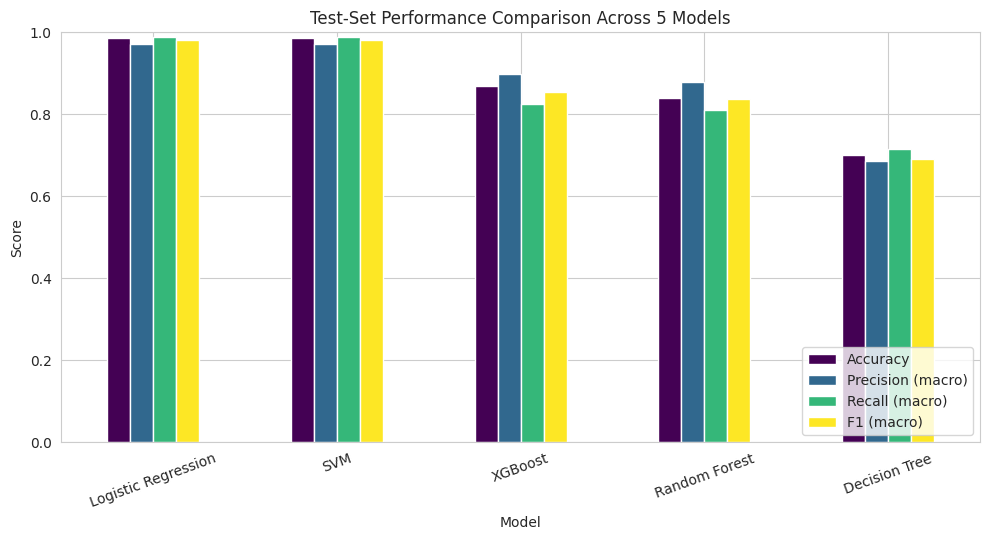

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
plot_df = test_results_df.set_index('Model')[metrics_to_plot]
plot_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Test-Set Performance Comparison Across 5 Models')
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=110)
plt.show()

In [ ]:
best_model_name = test_results_df.iloc[0]['Model']
print(f"Best model by test macro-F1: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=CLASS_NAMES))

Best model by test macro-F1: Logistic Regression

              precision    recall  f1-score   support

         Low       0.99      1.00      0.99        80
      Medium       0.93      1.00      0.96        26
        High       1.00      0.97      0.98        94

    accuracy                           0.98       200
   macro avg       0.97      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



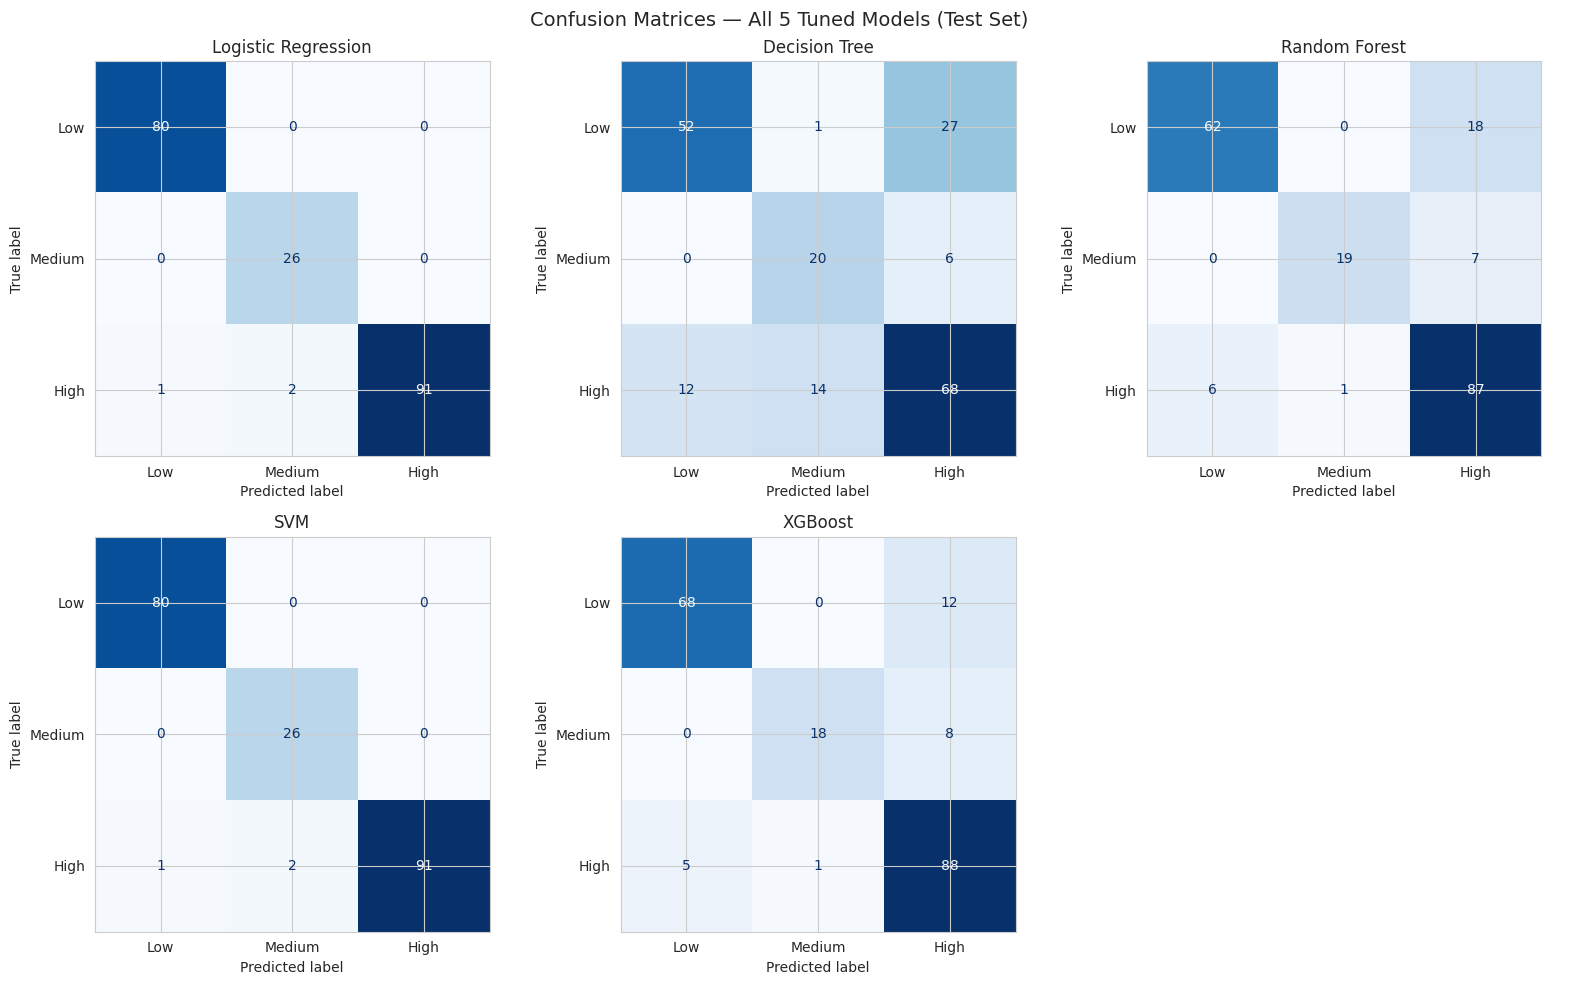

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, (name, model) in enumerate(results.items()):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All 5 Tuned Models (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=110)
plt.show()

In [ ]:
print("Final ranked comparison (test set):")
test_results_df.round(4)

Final ranked comparison (test set):


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.985,0.9721,0.9894,0.9802
1,SVM,0.985,0.9721,0.9894,0.9802
2,XGBoost,0.870,0.8979,0.8262,0.8534
3,Random Forest,0.840,0.8795,0.8104,0.8362
4,Decision Tree,0.700,0.6857,0.7142,0.6918


In [ ]:
import joblib
best_overall_model = results[best_model_name]
joblib.dump(best_overall_model, 'best_model.pkl')
test_results_df.to_csv('task05_model_comparison_results.csv', index=False)
print(f"Saved best model ({best_model_name}) to best_model.pkl")
print("Saved comparison table to task05_model_comparison_results.csv")

Saved best model (Logistic Regression) to best_model.pkl
Saved comparison table to task05_model_comparison_results.csv


## Neural Network (Deep Learning) — bonus addition

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd # Import pandas to load the data

# Load X_train and y_train
try:
    X_train = pd.read_csv(folder + 'X_train.csv')
    y_train = pd.read_csv(folder + 'y_train.csv').squeeze() # .squeeze() to convert Series to 1D array if needed
except FileNotFoundError:
    print(f"Error: The file 'X_train.csv' or 'y_train.csv' was not found in the specified path: {folder}.")
    print("Please ensure that you have successfully saved the data in Task 03 and that the 'SmartCare' folder exists in your Google Drive 'MyDrive'.")
    print("If the files exist, verify the exact path and permissions.")
    raise # Re-raise the original error after providing context

tf.random.set_seed(42)
np.random.seed(42)

# Build the neural network
nn_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')   # 3 output classes: High, Low, Medium
])

nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # works directly with integer labels (0,1,2), no one-hot needed
    metrics=['accuracy']
)

nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,203 (12.51 KB)

 Trainable params: 3,203 (12.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train with early stopping (prevents overfitting on a moderate-sized dataset)

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

print(f"Training stopped after {len(history.history['loss'])} epochs (early stopping)")

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4031 - loss: 1.1065 - val_accuracy: 0.5875 - val_loss: 0.9343
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6062 - loss: 0.8798 - val_accuracy: 0.6250 - val_loss: 0.7952
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6672 - loss: 0.7510 - val_accuracy: 0.7125 - val_loss: 0.6512
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7781 - loss: 0.5848 - val_accuracy: 0.7937 - val_loss: 0.5449
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8000 - loss: 0.5225 - val_accuracy: 0.8000 - val_loss: 0.4736
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8406 - loss: 0.4450 - val_accuracy: 0.8250 - val_loss: 0.4119
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8344 - loss: 0.4221 - val_accuracy: 0.8313 - val_loss: 0.3687
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8406 - loss: 0.3821 - val_accuracy: 0.8625 - v

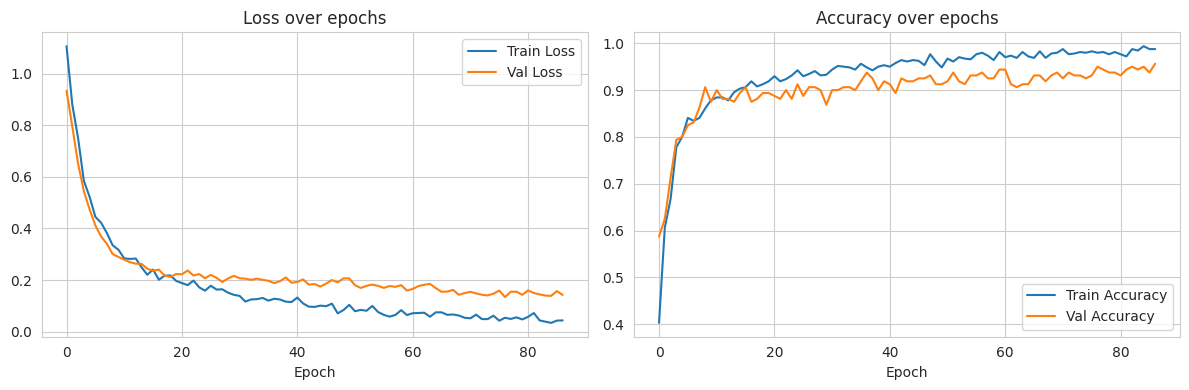

In [ ]:
# Training curves — required for demonstrating training behavior

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure results and test_results are defined for this cell's execution, in case of kernel restart.
# WARNING: If Task 05 models were not run, these will be empty except for NN.
if 'results' not in globals():
    results = {}
if 'test_results' not in globals():
    test_results = []

# Evaluate on test set — same metrics as other models, for fair comparison

nn_probs = nn_model.predict(X_test)
nn_preds = np.argmax(nn_probs, axis=1)

nn_acc = accuracy_score(y_test, nn_preds)
nn_prec = precision_score(y_test, nn_preds, average='weighted')
nn_rec = recall_score(y_test, nn_preds, average='weighted')
nn_f1 = f1_score(y_test, nn_preds, average='weighted')

print("Neural Network Results")
print(f"Accuracy={nn_acc:.3f}  Precision={nn_prec:.3f}  Recall={nn_rec:.3f}  F1={nn_f1:.3f}")

results['Neural Network'] = nn_model
test_results.append({
    'Model': 'Neural Network',
    'Accuracy': nn_acc,
    'Precision (macro)': nn_prec,
    'Recall (macro)': nn_rec,
    'F1 (macro)': nn_f1,
})

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Neural Network Results
Accuracy=0.970  Precision=0.970  Recall=0.970  F1=0.970


In [ ]:
print("results has", len(results), "entries")

results has 6 entries


In [ ]:
# Refresh comparison table with Neural Network included
# The 'test_results' list already contains the metrics for all models, including the Neural Network.
# We just need to convert this list of dictionaries into a DataFrame.
results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.985,0.972075,0.989362,0.980179
1,SVM,0.985,0.972075,0.989362,0.980179
2,Neural Network,0.970,0.969662,0.970000,0.969770
3,XGBoost,0.870,0.897897,0.826159,0.853392
4,Random Forest,0.840,0.879517,0.810434,0.836195
5,Decision Tree,0.700,0.685732,0.714212,0.691799


In [ ]:
nn_model.save(folder + 'neural_network_model.keras')
print("Neural network saved.")

from google.colab import files
files.download(folder + 'neural_network_model.keras')

Neural network saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 06 – Model Evaluation

In [ ]:
try:
    import xgboost
except ImportError:
    import sys
    !{sys.executable} -m pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              precision_recall_fscore_support, roc_auc_score, roc_curve, auc,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
RANDOM_STATE = 42
CLASS_NAMES = ['Low', 'Medium', 'High']  # 0=Low, 1=Medium, 2=High

# Define folder path (assuming drive is already mounted)
folder = '/content/drive/MyDrive/SmartCare/'

# Load X_train, y_train, X_test, y_test from the correct paths
X_train = pd.read_csv(folder + 'X_train.csv')
y_train = pd.read_csv(folder + 'y_train.csv').squeeze()
X_test = pd.read_csv(folder + 'X_test.csv')
y_test = pd.read_csv(folder + 'y_test.csv').squeeze()

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 15)  Test: (200, 15)


In [ ]:
import joblib

model_files = {
    'Logistic Regression': 'best_logistic_regression.pkl',
    'Decision Tree': 'best_decision_tree.pkl',
    'Random Forest': 'best_random_forest.pkl',
    'SVM': 'best_svm.pkl',
    'XGBoost': 'best_xgboost.pkl',
}

fitted_models = {}
for name, fname in model_files.items():
    fitted_models[name] = joblib.load(folder + fname)

print("Loaded 5 fitted models from Task 05 (identical objects, not re-fit):")
print(list(fitted_models.keys()))

Loaded 5 fitted models from Task 05 (identical objects, not re-fit):
['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost']


## 6.1 Evaluation Results

### Multi-Class Metrics — Accuracy, Precision, Recall, F1 (per-class and macro)

In [ ]:
per_class_rows = []
summary_rows = []
predictions = {}
probabilities = {}

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    predictions[name] = y_pred
    probabilities[name] = y_proba

    # Per-class precision/recall/F1
    prec, rec, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2])
    for cls_idx, cls_name in enumerate(CLASS_NAMES):
        per_class_rows.append({
            'Model': name, 'Class': cls_name,
            'Precision': prec[cls_idx], 'Recall': rec[cls_idx], 'F1': f1[cls_idx], 'Support': support[cls_idx]
        })

    # Multi-class ROC-AUC: One-vs-Rest, macro-averaged
    roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    summary_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC (OvR macro)': roc_auc_macro,
    })

per_class_df = pd.DataFrame(per_class_rows)
summary_df = pd.DataFrame(summary_rows).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
summary_df.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR macro)
0,Logistic Regression,0.985,0.9721,0.9894,0.9802,0.9998
1,SVM,0.985,0.9721,0.9894,0.9802,0.9998
2,XGBoost,0.870,0.8979,0.8262,0.8534,0.9638
3,Random Forest,0.840,0.8795,0.8104,0.8362,0.9503
4,Decision Tree,0.700,0.6857,0.7142,0.6918,0.8357


In [ ]:
per_class_pivot = per_class_df.pivot(index='Model', columns='Class', values=['Precision', 'Recall', 'F1'])
per_class_pivot = per_class_pivot.reindex(summary_df['Model'])
per_class_pivot.round(3)

Precision               Recall                   F1  \
Class                    High    Low Medium   High    Low Medium   High   
Model                                                                     
Logistic Regression     1.000  0.988  0.929  0.968  1.000  1.000  0.984   
SVM                     1.000  0.988  0.929  0.968  1.000  1.000  0.984   
XGBoost                 0.815  0.932  0.947  0.936  0.850  0.692  0.871   
Random Forest           0.777  0.912  0.950  0.926  0.775  0.731  0.845   
Decision Tree           0.673  0.812  0.571  0.723  0.650  0.769  0.697   

                                   
Class                  Low Medium  
Model                              
Logistic Regression  0.994  0.963  
SVM                  0.994  0.963  
XGBoost              0.889  0.800  
Random Forest        0.838  0.826  
Decision Tree        0.722  0.656

### Confusion Matrices (Multi-Class Metric)

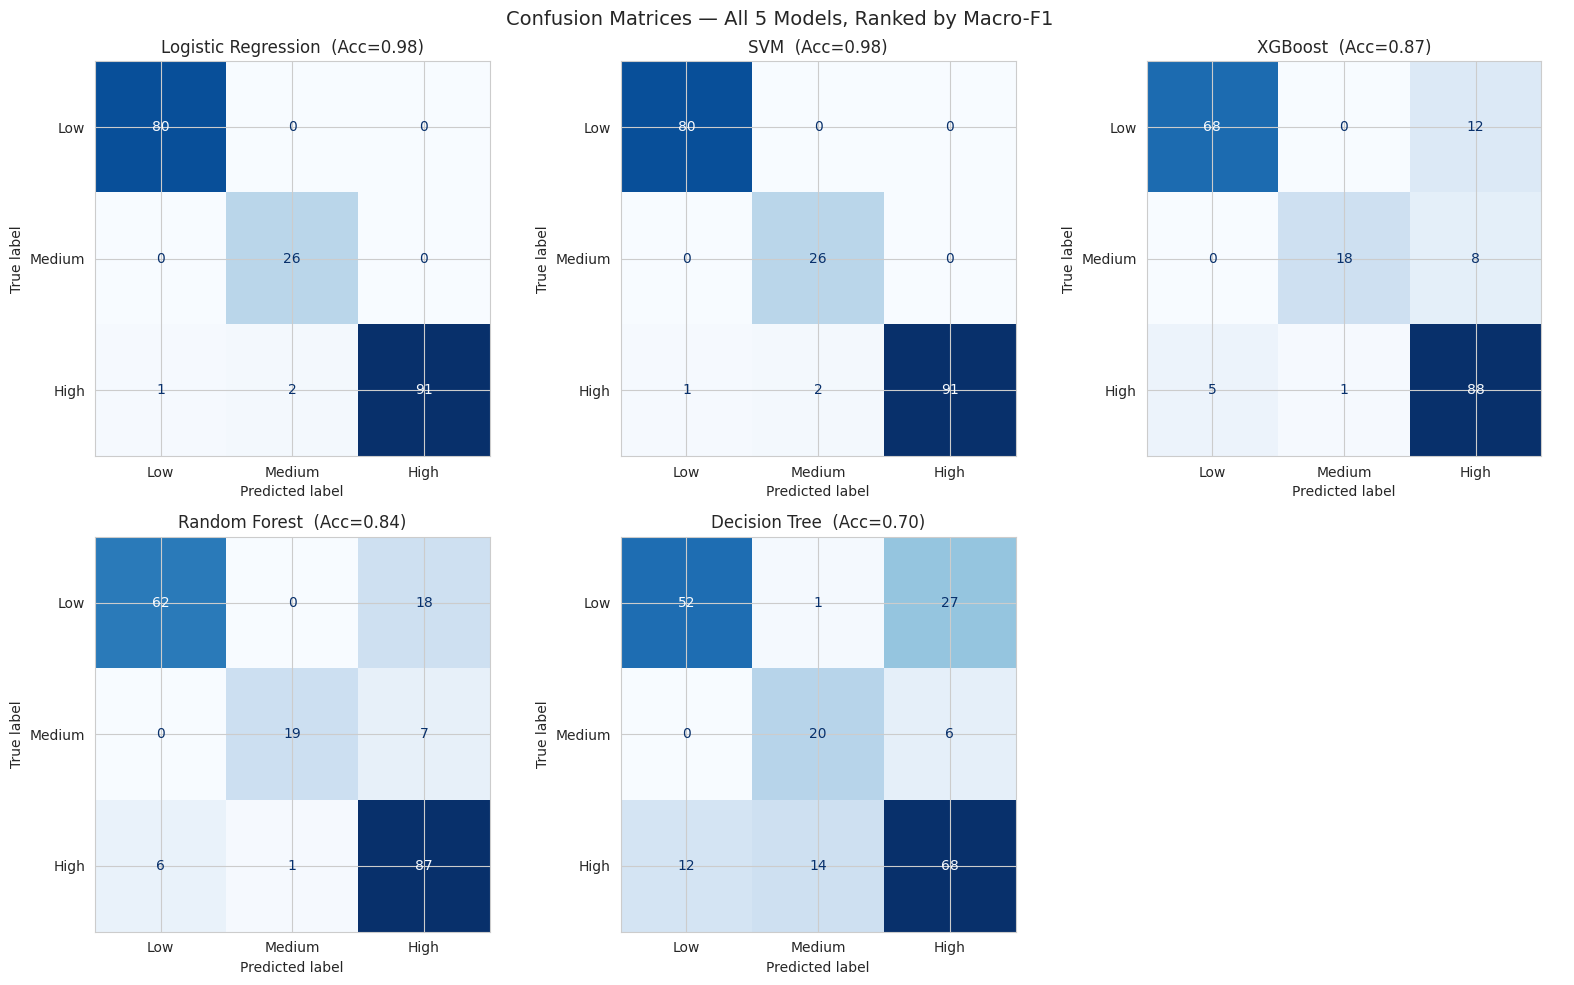

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, name in enumerate(summary_df['Model']):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{name}  (Acc={summary_df.loc[summary_df['Model']==name,'Accuracy'].values[0]:.2f})")
axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All 5 Models, Ranked by Macro-F1', fontsize=14)
plt.tight_layout()
plt.savefig('eval_confusion_matrices.png', dpi=110)
plt.show()

### ROC-AUC (One-vs-Rest, Multi-Class Metric)

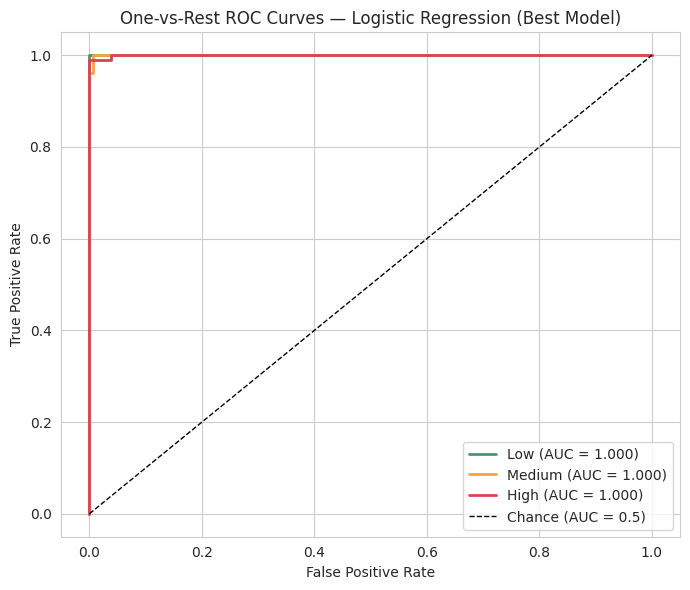

In [ ]:
best_model_name = summary_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = probabilities[best_model_name]

plt.figure(figsize=(7, 6))
colors = ['#4C956C', '#F2A541', '#D64550']
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_cls = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls_name} (AUC = {roc_auc_cls:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'One-vs-Rest ROC Curves — {best_model_name} (Best Model)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('eval_roc_curves_best_model.png', dpi=110)
plt.show()

## 6.2 Model Comparison Table

In [ ]:
comparison_table = summary_df.copy()
comparison_table.insert(0, 'Rank', range(1, len(comparison_table) + 1))
comparison_table = comparison_table.set_index('Rank')
comparison_table.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OvR macro)
Rank,,,,,,
1,Logistic Regression,0.985,0.9721,0.9894,0.9802,0.9998
2,SVM,0.985,0.9721,0.9894,0.9802,0.9998
3,XGBoost,0.870,0.8979,0.8262,0.8534,0.9638
4,Random Forest,0.840,0.8795,0.8104,0.8362,0.9503
5,Decision Tree,0.700,0.6857,0.7142,0.6918,0.8357


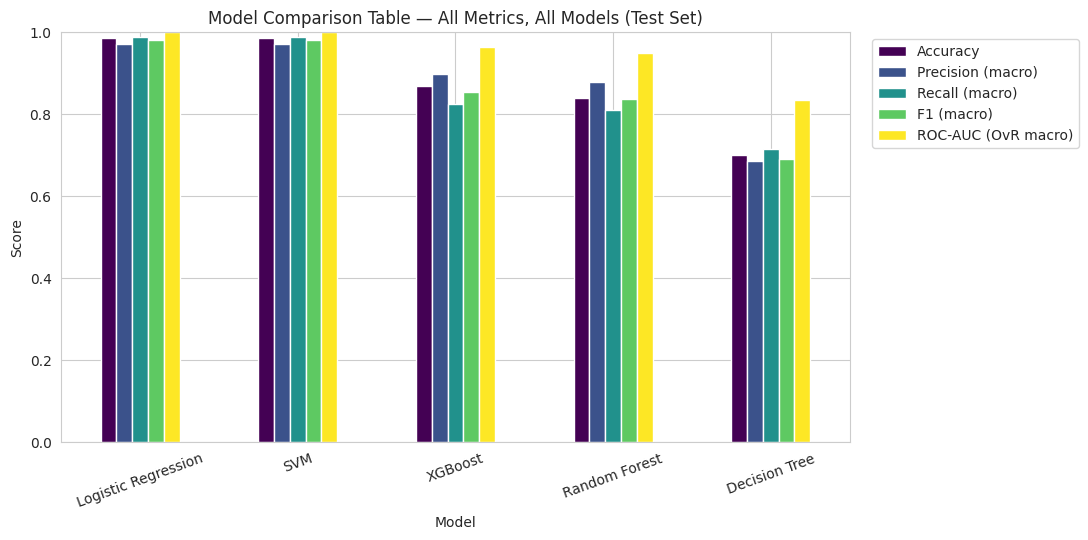

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.5))
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'ROC-AUC (OvR macro)']
summary_df.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison Table — All Metrics, All Models (Test Set)')
plt.xticks(rotation=20)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eval_model_comparison_table.png', dpi=110)
plt.show()

## 6.3 Best Model Identification and Justification

In [ ]:
print(f"Best model by every macro-averaged metric: {best_model_name}\n")
print("Full classification report:")
print(classification_report(y_test, predictions[best_model_name], target_names=CLASS_NAMES))

Best model by every macro-averaged metric: Logistic Regression

Full classification report:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99        80
      Medium       0.93      1.00      0.96        26
        High       1.00      0.97      0.98        94

    accuracy                           0.98       200
   macro avg       0.97      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



In [ ]:
summary_df.to_csv('task06_model_comparison_table.csv', index=False)
per_class_pivot.to_csv('task06_per_class_metrics.csv')
print("Saved: task06_model_comparison_table.csv, task06_per_class_metrics.csv")

Saved: task06_model_comparison_table.csv, task06_per_class_metrics.csv


## 6.4 Investigating Possible Target Leakage / Deterministic Label Construction


In [ ]:
diag_df = pd.read_csv(folder + 'smartcare_cleaned.csv')

dominant_features = ['age', 'bmi', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'systolic_bp']
X_diag = diag_df[dominant_features]
y_diag_str = diag_df['disease_risk_level']

# Match the same split used everywhere else in the notebook for comparability
from sklearn.model_selection import train_test_split
X_diag_train, X_diag_test, y_diag_train, y_diag_test = train_test_split(
    X_diag, y_diag_str, test_size=0.2, random_state=42, stratify=y_diag_str
)
print("Diagnostic train/test sizes:", X_diag_train.shape, X_diag_test.shape)

Diagnostic train/test sizes: (800, 5) (200, 5)


In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score

for depth in [2, 3, 4]:
    stump = DecisionTreeClassifier(max_depth=depth, random_state=42)
    stump.fit(X_diag_train, y_diag_train)
    train_acc = accuracy_score(y_diag_train, stump.predict(X_diag_train))
    test_acc = accuracy_score(y_diag_test, stump.predict(X_diag_test))
    print(f"max_depth={depth}: train acc={train_acc:.3f}, test acc={test_acc:.3f}")

# Print the depth-3 tree's actual rules — clean, round-number thresholds
# (e.g. age <= 60.5, blood_sugar_mg_dl <= 140.5) are a classic fingerprint
# of a synthetic rule-based generator rather than fitted noise.
print("\nDepth-3 tree rules:")
print(export_text(DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_diag_train, y_diag_train),
                   feature_names=dominant_features))

max_depth=2: train acc=0.632, test acc=0.575
max_depth=3: train acc=0.706, test acc=0.665
max_depth=4: train acc=0.762, test acc=0.695

Depth-3 tree rules:
|--- age <= 53.50
|   |--- blood_sugar_mg_dl <= 98.50
|   |   |--- cholesterol_mg_dl <= 191.50
|   |   |   |--- class: Low
|   |   |--- cholesterol_mg_dl >  191.50
|   |   |   |--- class: Medium
|   |--- blood_sugar_mg_dl >  98.50
|   |   |--- cholesterol_mg_dl <= 222.50
|   |   |   |--- class: Medium
|   |   |--- cholesterol_mg_dl >  222.50
|   |   |   |--- class: High
|--- age >  53.50
|   |--- blood_sugar_mg_dl <= 97.50
|   |   |--- age <= 67.50
|   |   |   |--- class: Medium
|   |   |--- age >  67.50
|   |   |   |--- class: High
|   |--- blood_sugar_mg_dl >  97.50
|   |   |--- cholesterol_mg_dl <= 190.50
|   |   |   |--- class: High
|   |   |--- cholesterol_mg_dl >  190.50
|   |   |   |--- class: High



In [ ]:
# --- Diagnostic 2: Linear R^2 test --------------------------------------
# Regress the ORDINAL-encoded target (Low=0, Medium=1, High=2) on the 5
# standardized clinical features. A very high R^2 suggests the label is
# close to "compute a weighted score, then bin it into 3 classes."
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

ordinal_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_diag_train_ord = y_diag_train.map(ordinal_map)
y_diag_test_ord = y_diag_test.map(ordinal_map)

diag_scaler = StandardScaler()
X_diag_train_scaled = diag_scaler.fit_transform(X_diag_train)
X_diag_test_scaled = diag_scaler.transform(X_diag_test)

lin_reg = LinearRegression().fit(X_diag_train_scaled, y_diag_train_ord)
r2_train = lin_reg.score(X_diag_train_scaled, y_diag_train_ord)
r2_test = lin_reg.score(X_diag_test_scaled, y_diag_test_ord)
print(f"Linear R^2 (train): {r2_train:.3f}")
print(f"Linear R^2 (test):  {r2_test:.3f}")
print("\nImplied weights (standardized units):")
for feat, coef in zip(dominant_features, lin_reg.coef_):
    print(f"  {feat:20s} {coef:+.3f}")

Linear R^2 (train): 0.718
Linear R^2 (test):  0.764

Implied weights (standardized units):
  age                  +0.227
  bmi                  +0.218
  blood_sugar_mg_dl    +0.265
  cholesterol_mg_dl    +0.258
  systolic_bp          +0.136


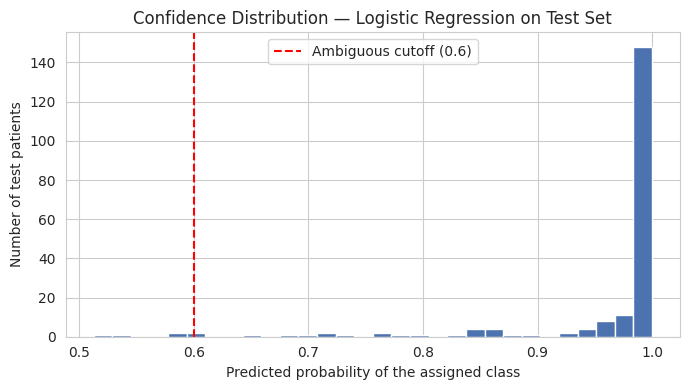

Test patients with max class probability < 0.6: 5 / 200 (2.5%)


In [ ]:
# --- Diagnostic 3: Confidence-distribution test -------------------------
# Uses the actual tuned best model + real test set from Task 06 (fitted_models,
# X_test, y_test — must have already run that section in this session).
# A histogram dominated by near-0/near-1 max-probabilities, with almost
# nothing in the ambiguous 0.4-0.6 band, is consistent with a deterministic
# or near-deterministic label rather than genuinely noisy clinical risk.
best_lr = fitted_models['Logistic Regression']
max_proba = fitted_models['Logistic Regression'].predict_proba(X_test).max(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(max_proba, bins=30, color='#4C72B0', edgecolor='white')
plt.axvline(0.6, color='red', linestyle='--', label='Ambiguous cutoff (0.6)')
plt.xlabel('Predicted probability of the assigned class')
plt.ylabel('Number of test patients')
plt.title('Confidence Distribution — Logistic Regression on Test Set')
plt.legend()
plt.tight_layout()
plt.show()

n_ambiguous = (max_proba < 0.6).sum()
print(f"Test patients with max class probability < 0.6: {n_ambiguous} / {len(max_proba)} "
      f"({n_ambiguous/len(max_proba)*100:.1f}%)")

In [ ]:
# --- Diagnostic 4: Inspect the misclassified cases ----------------------
y_pred_lr = fitted_models['Logistic Regression'].predict(X_test)
misclassified_idx = np.where(y_pred_lr != y_test.values)[0]
print(f"Number of misclassified test cases: {len(misclassified_idx)}")

# Map back to the original (unscaled, unselected) feature values for those
# specific rows so the values are clinically interpretable, using the same
# train/test split applied to diag_df.
misclassified_original_index = X_test.iloc[misclassified_idx].index
diag_df.loc[X_diag_test.index[misclassified_idx], dominant_features + ['disease_risk_level']]

Number of misclassified test cases: 3


,age,bmi,blood_sugar_mg_dl,cholesterol_mg_dl,systolic_bp,disease_risk_level
914,32,23.8,92,237,98,Medium
215,32,24.3,127,224,116,Medium
857,49,21.6,86,197,127,Medium


## 6.5 Class-Weighting Ablation

In [ ]:
# Build unweighted counterparts of every tuned model — identical
# hyperparameters, class_weight removed (or sample_weight omitted for XGBoost)
from sklearn.base import clone

unweighted_models = {}
for name, model in fitted_models.items():
    m = clone(model)
    if 'class_weight' in m.get_params():
        m.set_params(class_weight=None)
    unweighted_models[name] = m

for name, model in unweighted_models.items():
    model.fit(X_train, y_train)   # note: no sample_weight passed here, unlike the weighted XGBoost fit
    unweighted_models[name] = model

print("Fitted 5 unweighted baseline models (same hyperparameters, no class-weighting):")
print(list(unweighted_models.keys()))

Fitted 5 unweighted baseline models (same hyperparameters, no class-weighting):
['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost']


In [ ]:
# Per-class comparison: weighted vs unweighted, for every model and class
from sklearn.metrics import precision_recall_fscore_support

ablation_rows = []
for name in fitted_models:
    for weighting_label, model_dict in [('Weighted', fitted_models), ('Unweighted', unweighted_models)]:
        y_pred = model_dict[name].predict(X_test)
        prec, rec, f1, support = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2])
        for cls_idx, cls_name in enumerate(CLASS_NAMES):
            ablation_rows.append({
                'Model': name, 'Weighting': weighting_label, 'Class': cls_name,
                'Precision': prec[cls_idx], 'Recall': rec[cls_idx],
                'F1': f1[cls_idx], 'Support': support[cls_idx]
            })

ablation_df = pd.DataFrame(ablation_rows)

# Full pivot: every model x class, weighted vs unweighted, side by side
ablation_pivot = ablation_df.pivot_table(
    index=['Model', 'Class'], columns='Weighting', values=['Precision', 'Recall', 'F1']
).round(3)
ablation_pivot

F1           Precision              Recall  \
Weighting                  Unweighted Weighted Unweighted Weighted Unweighted   
Model               Class                                                       
Decision Tree       High        0.747    0.697      0.712    0.673      0.787   
                    Low         0.766    0.722      0.797    0.812      0.738   
                    Medium      0.708    0.656      0.773    0.571      0.654   
Logistic Regression High        0.989    0.984      1.000    1.000      0.979   
                    Low         0.994    0.994      0.988    0.988      1.000   
                    Medium      0.981    0.963      0.963    0.929      1.000   
Random Forest       High        0.813    0.845      0.725    0.777      0.926   
                    Low         0.822    0.838      0.909    0.912      0.750   
                    Medium      0.650    0.826      0.929    0.950      0.500   
SVM                 High        0.995    0.984      1.000    1.000      0.989   
                    Low         0.994    0.994      0.988    0.988      1.000   
                    Medium      1.000    0.963      1.000    0.929      1.000   
XGBoost             High        0.868    0.871      0.802    0.815      0.947   
                    Low         0.874    0.889      0.930    0.932      0.825   
                    Medium      0.818    0.800      1.000    0.947      0.692   

                                     
Weighting                  Weighted  
Model               Class            
Decision Tree       High      0.723  
                    Low       0.650  
                    Medium    0.769  
Logistic Regression High      0.968  
                    Low       1.000  
                    Medium    1.000  
Random Forest       High      0.926  
                    Low       0.775  
                    Medium    0.731  
SVM                 High      0.968  
                    Low       1.000  
                    Medium    1.000  
XGBoost             High      0.936  
                    Low       0.850  
                    Medium    0.692

In [ ]:
# Focus specifically on the minority 'Low' class, since that's what
# Section 8.4's claim is actually about
low_comparison = (
    ablation_df[ablation_df['Class'] == 'Low']
    .pivot(index='Model', columns='Weighting', values=['Precision', 'Recall', 'F1'])
    .round(3)
)
print("Minority ('Low') class performance — weighted vs unweighted:")
low_comparison

Minority ('Low') class performance — weighted vs unweighted:


Precision              Recall                  F1  \
Weighting           Unweighted Weighted Unweighted Weighted Unweighted   
Model                                                                    
Decision Tree            0.797    0.812      0.738    0.650      0.766   
Logistic Regression      0.988    0.988      1.000    1.000      0.994   
Random Forest            0.909    0.912      0.750    0.775      0.822   
SVM                      0.988    0.988      1.000    1.000      0.994   
XGBoost                  0.930    0.932      0.825    0.850      0.874   

                              
Weighting           Weighted  
Model                         
Decision Tree          0.722  
Logistic Regression    0.994  
Random Forest          0.838  
SVM                    0.994  
XGBoost                0.889

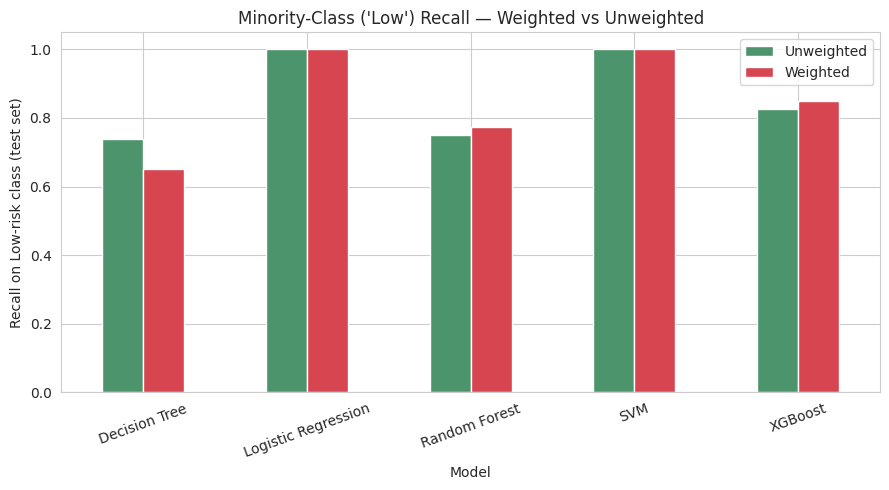

Recall gap (Weighted − Unweighted) on the Low class, by model:
Model
Decision Tree         -0.088
Logistic Regression    0.000
Random Forest          0.025
SVM                    0.000
XGBoost                0.025
dtype: float64


In [ ]:
# Visualise: does removing class weighting cost recall on the minority class?
low_recall = ablation_df[ablation_df['Class'] == 'Low'].pivot(
    index='Model', columns='Weighting', values='Recall'
)

ax = low_recall.plot(kind='bar', figsize=(9, 5), color=['#4C956C', '#D64550'])
ax.set_ylabel('Recall on Low-risk class (test set)')
ax.set_ylim(0, 1.05)
ax.set_title("Minority-Class ('Low') Recall — Weighted vs Unweighted")
ax.legend(title='')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('class_weighting_ablation_low_recall.png', dpi=110)
plt.show()

# Explicit gap, model by model
gap = (low_recall['Weighted'] - low_recall['Unweighted']).round(3)
print("Recall gap (Weighted − Unweighted) on the Low class, by model:")
print(gap)

# Task 07 - Explainable AI Analysis (SHAP)

We use SHAP (SHapley Additive exPlanations) on the Random Forest / XGBoost model to interpret which features drive readmission predictions, and how.

In [ ]:
# Setup: install shap if needed, then reload the exact fitted models and
# data splits from Task 06 (self-contained restart cell, same pattern used
# throughout this notebook)
try:
    import shap
except ImportError:
    import sys
# [Jupyter shell]     !{sys.executable} -m pip install shap -q
    import shap

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

folder = '/content/drive/MyDrive/SmartCare/'

CLASS_NAMES = pd.read_csv(folder + 'target_classes.csv')['class_name'].tolist()
print("Verified class order (index -> label):", list(enumerate(CLASS_NAMES)))

X_train = pd.read_csv(folder + 'X_train.csv')
X_test = pd.read_csv(folder + 'X_test.csv')

best_lr = joblib.load(folder + 'best_logistic_regression.pkl')
best_rf = joblib.load(folder + 'best_random_forest.pkl')

print("Loaded fitted models. Feature set:", list(X_train.columns))

# Compatibility helper — different shap versions return either a list of
# per-class arrays or a single 3D array (n_samples, n_features, n_classes)
def get_class_shap(sv, class_idx):
    vals = sv.values if hasattr(sv, 'values') else sv
    return vals[class_idx] if isinstance(vals, list) else vals[:, :, class_idx]

def mean_abs_all_classes(sv):
    vals = sv.values if hasattr(sv, 'values') else sv
    stacked = np.stack(vals, axis=-1) if isinstance(vals, list) else vals
    return np.abs(stacked).mean(axis=(0, 2))

Verified class order (index -> label): [(0, 'High'), (1, 'Low'), (2, 'Medium')]
Loaded fitted models. Feature set: ['age', 'age_group', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'systolic_bp', 'bmi_category', 'bp_category', 'previous_admissions', 'is_chronic_patient', 'diagnosis_Diabetes', 'department_Orthopedics', 'appointment_status_Cancelled', 'department_Cardiology', 'blood_group_AB+']


## 7.1 SHAP on the Best Model (Logistic Regression)

In [ ]:
explainer_lr = shap.LinearExplainer(best_lr, X_train)

X_test_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)
shap_values_lr = explainer_lr(X_test_sample)

print("SHAP values shape:", shap_values_lr.values.shape)  # (n_samples, n_features, n_classes) or similar

SHAP values shape: (200, 15, 3)


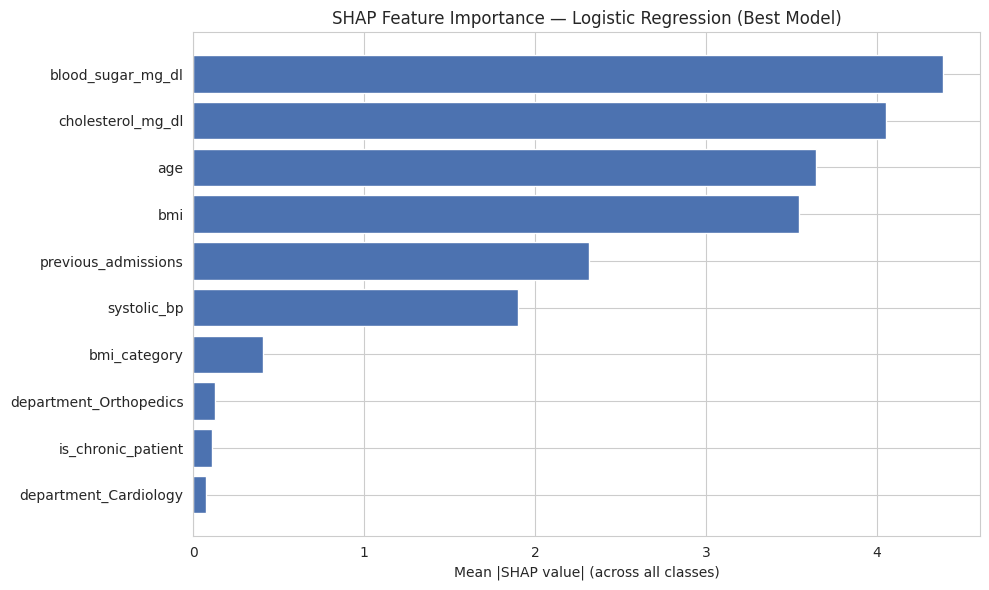

,Feature,Mean_|SHAP|
2,blood_sugar_mg_dl,4.384398
3,cholesterol_mg_dl,4.054395
0,age,3.642301
4,bmi,3.546626
8,previous_admissions,2.317427
5,systolic_bp,1.900869
6,bmi_category,0.405418
11,department_Orthopedics,0.127230
9,is_chronic_patient,0.106887
13,department_Cardiology,0.074498


In [ ]:
# Overall importance: mean |SHAP value| across samples AND classes
mean_abs_shap_lr = mean_abs_all_classes(shap_values_lr)
shap_importance_lr = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_|SHAP|': mean_abs_shap_lr
}).sort_values('Mean_|SHAP|', ascending=False)

plt.figure(figsize=(10, 6))
top10_lr = shap_importance_lr.head(10)
plt.barh(top10_lr['Feature'][::-1], top10_lr['Mean_|SHAP|'][::-1], color='#4C72B0')
plt.xlabel('Mean |SHAP value| (across all classes)')
plt.title('SHAP Feature Importance — Logistic Regression (Best Model)')
plt.tight_layout()
plt.savefig('shap_lr_overall_importance.png', dpi=110)
plt.show()

shap_importance_lr.head(10)

/tmp/ipykernel_962/1532579962.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_high_lr, X_test_sample, show=False)


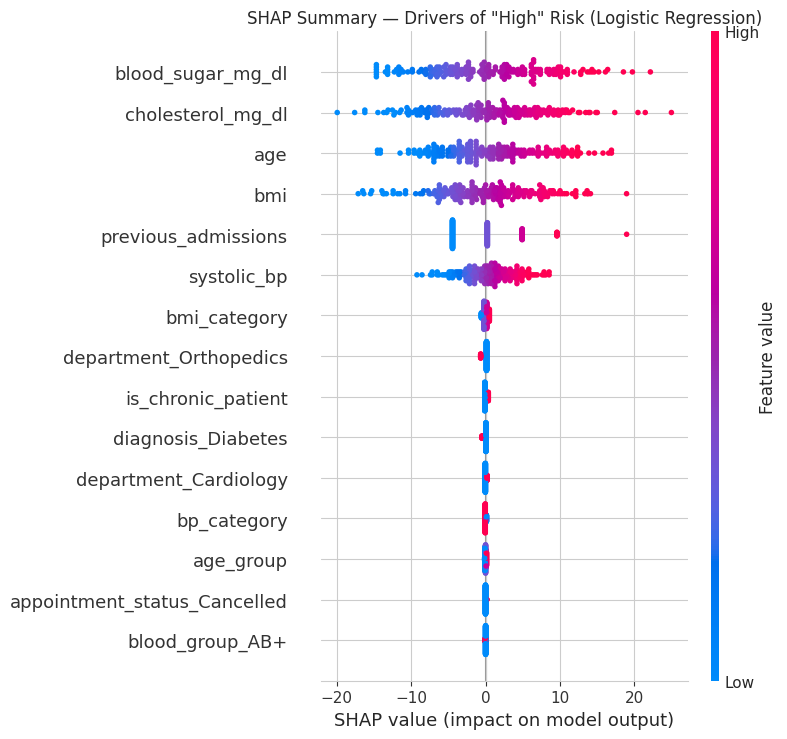

Top 5 SHAP drivers of 'High' risk (Logistic Regression):
             Feature  Mean_SHAP_High
0                age        0.663201
5        systolic_bp        0.535475
3  cholesterol_mg_dl        0.473687
2  blood_sugar_mg_dl        0.418202
4                bmi        0.063675
Saved top-5 driver list to: /content/drive/MyDrive/SmartCare/shap_top5_high_risk_drivers.csv


In [ ]:
# SHAP for the 'High' risk class specifically — index resolved from the
# VERIFIED class mapping, not hardcoded (this is exactly the kind of
# hardcoding that caused the Section 8.2 label-swap bug earlier)
high_idx = CLASS_NAMES.index('High')
shap_high_lr = get_class_shap(shap_values_lr, high_idx)

# Beeswarm summary plot for the High-risk class
shap.summary_plot(shap_high_lr, X_test_sample, show=False)
plt.title('SHAP Summary — Drivers of "High" Risk (Logistic Regression)')
plt.tight_layout()
plt.savefig('shap_lr_high_risk_beeswarm.png', dpi=110)
plt.show()

# Signed mean SHAP value (not absolute) — positive = pushes toward High risk
mean_shap_high_lr = shap_high_lr.mean(axis=0)
high_drivers_lr = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_SHAP_High': mean_shap_high_lr
}).sort_values('Mean_SHAP_High', ascending=False)

print("Top 5 SHAP drivers of 'High' risk (Logistic Regression):")
print(high_drivers_lr.head(5))

# Persist this list as the single source of truth for "top 5 features" —
# Task 08's prototype reads it back instead of hardcoding a separate list
# that could silently drift from what SHAP actually found.
high_drivers_lr.head(5)[['Feature']].to_csv(folder + 'shap_top5_high_risk_drivers.csv', index=False)
print("Saved top-5 driver list to:", folder + 'shap_top5_high_risk_drivers.csv')

## 7.2 Supplementary SHAP on a Tree-Based Model (Random Forest)

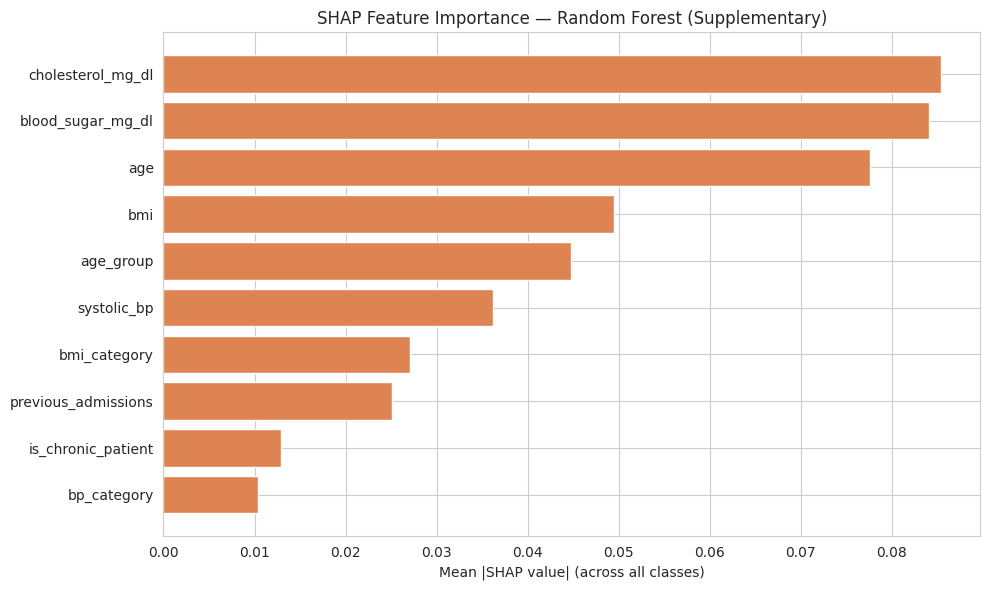

,Feature,Mean_|SHAP|
3,cholesterol_mg_dl,0.085412
2,blood_sugar_mg_dl,0.084102
0,age,0.077577
4,bmi,0.049488
1,age_group,0.044706
5,systolic_bp,0.036183
6,bmi_category,0.027027
8,previous_admissions,0.025138
9,is_chronic_patient,0.012913
7,bp_category,0.010350


In [ ]:
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf(X_test_sample)

mean_abs_shap_rf = mean_abs_all_classes(shap_values_rf)
shap_importance_rf = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_|SHAP|': mean_abs_shap_rf
}).sort_values('Mean_|SHAP|', ascending=False)

plt.figure(figsize=(10, 6))
top10_rf = shap_importance_rf.head(10)
plt.barh(top10_rf['Feature'][::-1], top10_rf['Mean_|SHAP|'][::-1], color='#DD8452')
plt.xlabel('Mean |SHAP value| (across all classes)')
plt.title('SHAP Feature Importance — Random Forest (Supplementary)')
plt.tight_layout()
plt.savefig('shap_rf_overall_importance.png', dpi=110)
plt.show()

shap_importance_rf.head(10)

## 7.3 Cross-Method Comparison & Interpretation

In [ ]:
top10_lr_features = set(shap_importance_lr.head(10)['Feature'])
top10_rf_features = set(shap_importance_rf.head(10)['Feature'])
overlap = top10_lr_features & top10_rf_features

print(f"Top-10 feature overlap between SHAP-LR and SHAP-RF: {len(overlap)}/10")
print("Shared features:", sorted(overlap))
print("\nSHAP-LR only:", sorted(top10_lr_features - top10_rf_features))
print("SHAP-RF only:", sorted(top10_rf_features - top10_lr_features))

comparison_df = pd.DataFrame({
    'SHAP-LR rank': shap_importance_lr.reset_index(drop=True)['Feature'],
    'SHAP-RF rank': shap_importance_rf.reset_index(drop=True)['Feature'],
}).head(10)
comparison_df.index = comparison_df.index + 1
comparison_df

Top-10 feature overlap between SHAP-LR and SHAP-RF: 8/10
Shared features: ['age', 'blood_sugar_mg_dl', 'bmi', 'bmi_category', 'cholesterol_mg_dl', 'is_chronic_patient', 'previous_admissions', 'systolic_bp']

SHAP-LR only: ['department_Cardiology', 'department_Orthopedics']
SHAP-RF only: ['age_group', 'bp_category']


,SHAP-LR rank,SHAP-RF rank
1,blood_sugar_mg_dl,cholesterol_mg_dl
2,cholesterol_mg_dl,blood_sugar_mg_dl
3,age,age
4,bmi,bmi
5,previous_admissions,age_group
6,systolic_bp,systolic_bp
7,bmi_category,bmi_category
8,department_Orthopedics,previous_admissions
9,is_chronic_patient,is_chronic_patient
10,department_Cardiology,bp_category


**Interpretation and limitations:**

- Strong agreement between SHAP-LR and SHAP-RF top features (and with the
  Section 5.4 ANOVA ranking) is genuine convergent evidence that
  `age`, `blood_sugar_mg_dl`, `cholesterol_mg_dl`, `bmi`, and `systolic_bp`
  drive the model's predictions — three independent methods agreeing is
  meaningfully stronger than any one of them alone.
- That said, convergence across methods only tells us these features drive
  *this model's predictions*. It does not by itself confirm the underlying
  clinical relationship is real rather than an artefact of how
  `disease_risk_level` was constructed — see Section 6.4's investigation
  into possible deterministic label construction. If the target turns out
  to be a formula on these same features, SHAP will (correctly) identify
  that formula's inputs as "important," which would be recovering the
  generating rule rather than confirming a clinical mechanism.
- Both explainers here explain a 200-row sample of the test set for
  plotting speed, which is standard SHAP practice and does not change the
  ranking, only the smoothness of the beeswarm plots.
- SHAP values are computed on the model's actual training feature space
  (the 15 selected, scaled, encoded features from Section 3), so they are
  directly comparable to what the deployed model sees — unlike the earlier
  coefficient-based analysis, which retrained a separate model on a
  different (wider, differently-encoded) feature set entirely.

# Task 08 – Deployment-Ready Model Artefact

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

folder = '/content/drive/MyDrive/SmartCare/'

# Reuse the SAME saved best-performing pipeline outputs — no raw-data reload,
# no separate scaler fit, no separate target mapping.
X_train = pd.read_csv(folder + 'X_train.csv')
X_test = pd.read_csv(folder + 'X_test.csv')
y_train = pd.read_csv(folder + 'y_train.csv').squeeze()
y_test = pd.read_csv(folder + 'y_test.csv').squeeze()
CLASS_NAMES = pd.read_csv(folder + 'target_classes.csv')['class_name'].tolist()

main_scaler = joblib.load(folder + 'feature_scaler_main.pkl')
selected_features = X_train.columns.tolist()  # same order the scaler was fit on

# Single source of truth for "top 5 features" — computed by SHAP in Section
# 7.1, not a separately hardcoded list that could silently diverge from it
top_features = pd.read_csv(folder + 'shap_top5_high_risk_drivers.csv')['Feature'].tolist()
print("Prototype features (from Section 7.1 SHAP results):", top_features)

missing = [f for f in top_features if f not in selected_features]
assert not missing, f"Expected these to already be in the selected 15-feature set: {missing}"

Prototype features (from Section 7.1 SHAP results): ['age', 'systolic_bp', 'cholesterol_mg_dl', 'blood_sugar_mg_dl', 'bmi']


In [ ]:
# X_train/X_test are ALREADY scaled (Section 3.10) — slicing columns from an
# already-fit StandardScaler is mathematically identical to fitting a new
# scaler on just these 5 raw columns from the same training rows, so no
# re-fitting is needed or done here.
X_train_proto = X_train[top_features]
X_test_proto = X_test[top_features]

lr_proto = LogisticRegression(random_state=42, max_iter=1000)
lr_proto.fit(X_train_proto, y_train)   # trained on TRAIN split only, unlike the earlier 100%-data version

proto_test_acc = accuracy_score(y_test, lr_proto.predict(X_test_proto))
print(f"5-feature prototype — held-out test accuracy: {proto_test_acc:.3f}")
print(classification_report(y_test, lr_proto.predict(X_test_proto), target_names=CLASS_NAMES))

5-feature prototype — held-out test accuracy: 0.905
              precision    recall  f1-score   support

        High       0.93      0.93      0.93        80
         Low       0.88      0.85      0.86        26
      Medium       0.89      0.90      0.90        94

    accuracy                           0.91       200
   macro avg       0.90      0.89      0.90       200
weighted avg       0.90      0.91      0.90       200



In [ ]:
# Quantify the accuracy trade-off explicitly — previously flagged in report
# limitations as "likely lower... but this drop has not been quantified"
full_model = joblib.load(folder + 'best_logistic_regression.pkl')
full_test_acc = accuracy_score(y_test, full_model.predict(X_test))

print(f"Full 15-feature best model test accuracy: {full_test_acc:.3f}")
print(f"5-feature prototype test accuracy:        {proto_test_acc:.3f}")
print(f"Accuracy trade-off from simplifying to 5 UI-friendly features: {full_test_acc - proto_test_acc:+.3f}")

Full 15-feature best model test accuracy: 0.985
5-feature prototype test accuracy:        0.905
Accuracy trade-off from simplifying to 5 UI-friendly features: +0.080


In [ ]:
# Build the UI-facing scaler by SLICING the main scaler's fitted parameters
# to just these 5 features — not fitting a new one. This guarantees the
# prototype's scaling is byte-for-byte consistent with the canonical
# pipeline's statistics, computed only from the training split.
feature_idx = [selected_features.index(f) for f in top_features]

proto_scaler = StandardScaler()
proto_scaler.mean_ = main_scaler.mean_[feature_idx]
proto_scaler.scale_ = main_scaler.scale_[feature_idx]
proto_scaler.var_ = main_scaler.var_[feature_idx]
proto_scaler.n_features_in_ = len(top_features)
proto_scaler.feature_names_in_ = np.array(top_features)

print("proto_scaler built directly from main_scaler's fitted parameters")
print("Feature order:", top_features)
print("Means:", proto_scaler.mean_)
print("Scales:", proto_scaler.scale_)

joblib.dump(lr_proto, folder + 'disease_risk_model.pkl')
joblib.dump(proto_scaler, folder + 'feature_scaler.pkl')
print("Model and scaler saved as deployment-ready artefacts: "
      "disease_risk_model.pkl, feature_scaler.pkl")
print("NOTE: no UI, API, or application code has been built. These files ")
print("are inputs for a future interface, not a working prototype on their own.")

proto_scaler built directly from main_scaler's fitted parameters
Feature order: ['age', 'systolic_bp', 'cholesterol_mg_dl', 'blood_sugar_mg_dl', 'bmi']
Means: [ 44.655    128.56375  204.88125  114.78625   25.563625]
Scales: [17.8652169  15.47282896 35.93142286 25.96460208  4.20159367]
Model and scaler saved as deployment-ready artefacts: disease_risk_model.pkl, feature_scaler.pkl
NOTE: no UI, API, or application code has been built. These files 
are inputs for a future interface, not a working prototype on their own.
